# Alternative tree: Splitting criterion based on linear splines for tree construction

In [1]:
import os, sys, importlib.util

# 1) Where Jupyter is currently running:
cwd = os.getcwd()
print("Notebook cwd:", cwd)

# 2) Compute the folder above (your project root):
project_root = os.path.abspath(os.path.join(cwd, os.pardir))
print("Project root:", project_root)
print("→ Contains:", os.listdir(project_root))

# 3) Inject it onto sys.path (highest priority):
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print("After hack, sys.path[0]:", sys.path[0])

# 4) Confirm Python can now see lmt_pkg:
print("After hack, spec(lmt_pkg):", importlib.util.find_spec("lmt_pkg"))

from lmt_pkg import lmt_final_implementation as lmt
from lmt_pkg import calibration_functions as calibration
from lmt_pkg import logitboost_j_implementation as logitboost
from lmt_pkg import composite_tree

Notebook cwd: c:\Users\allis\Desktop\MITACS\LMT-calibration\Alternative tree (linear spline)
Project root: c:\Users\allis\Desktop\MITACS\LMT-calibration
→ Contains: ['.git', 'Alternative pruning', 'Alternative tree (linear spline)', 'Alternative tree (root multi-cuts)', 'Calibration testing', 'Construction and tests', 'Documentation', 'lmt_pkg', 'Papers', 'README.md']
After hack, sys.path[0]: c:\Users\allis\Desktop\MITACS\LMT-calibration
After hack, spec(lmt_pkg): ModuleSpec(name='lmt_pkg', loader=<_frozen_importlib_external.SourceFileLoader object at 0x000001F62353BAC0>, origin='c:\\Users\\allis\\Desktop\\MITACS\\LMT-calibration\\lmt_pkg\\__init__.py', submodule_search_locations=['c:\\Users\\allis\\Desktop\\MITACS\\LMT-calibration\\lmt_pkg'])


In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

In [3]:
# ------------------------
# Node Classes
# ------------------------

class LeafNode:
    def __init__(self, y, node_id):
        self.is_leaf = True
        self.n_samples = len(y)
        self.value = np.bincount(y, minlength=2)
        self.prediction = np.argmax(self.value)
        self.node_id = node_id

class DecisionNode:
    def __init__(self, feature, tau, left, right, y, node_id):
        self.is_leaf = False
        self.feature = feature
        self.tau = tau
        self.left = left
        self.right = right
        self.n_samples = len(y)
        self.value = np.bincount(y, minlength=2)
        self.node_id = node_id
        #self.prediction = np.argmax(self.value)

# ------------------------
# Utility Functions
# ------------------------

def purity(y):
    """Returns the maximum class proportion"""
    counts = np.bincount(y)
    return counts.max() / counts.sum()

def fit_logistic_spline(X, y):
    """Fits logistic regression on a 2D array with linear spline terms"""
    model = LogisticRegression(solver='lbfgs', max_iter=1000)
    model.fit(X, y)
    return model

def compute_auc(model, X, y):
    """Computes AUC given model and input"""
    prob = model.predict_proba(X)[:, 1]

    # Just one class present
    if len(np.unique(y)) < 2:
        return 1
    return roc_auc_score(y, prob)

# ------------------------
# Recursive Tree Builder
# ------------------------

def grow_spline_tree(X, y, features, depth=0,
                     max_depth=3, min_samples_leaf=10,
                     purity_threshold=0.95, verbose=False, node_id_counter=[0]):
    """
    node_id_counter : list of 1 element acting as mutable counter (default [0])
    """
    n = len(y)

    if depth >= max_depth or n < 2 * min_samples_leaf or purity(y) >= purity_threshold:
        node_id = node_id_counter[0]
        node_id_counter[0] += 1
        return LeafNode(y, node_id)

    best_auc = -np.inf
    best_split = None

    for feature in features:
        X_j = X[:, feature]
        taus = np.quantile(X_j, np.linspace(0.1, 0.9, 9))

        for tau in taus:
            spline_term = np.maximum(0, X_j - tau).reshape(-1, 1)
            X_feat = X_j.reshape(-1, 1)
            X_model = np.hstack([X_feat, spline_term])

            try:
                model = fit_logistic_spline(X_model, y)
            except ValueError:
                continue

            mask_left = X_j <= tau
            mask_right = ~mask_left

            if mask_left.sum() < min_samples_leaf or mask_right.sum() < min_samples_leaf:
                continue

            auc_L = compute_auc(model, X_model[mask_left], y[mask_left])
            auc_R = compute_auc(model, X_model[mask_right], y[mask_right])
            weighted_auc = (mask_left.sum() / n) * auc_L + (mask_right.sum() / n) * auc_R

            if verbose:
                print(f"Feature {feature}, tau = {tau:.2f}, AUC_L = {auc_L:.3f}, AUC_R = {auc_R:.3f}, Weighted AUC = {weighted_auc:.3f}")

            if weighted_auc > best_auc:
                best_auc = weighted_auc
                best_split = {
                    'feature': feature,
                    'tau': tau,
                    'X_left': X[mask_left],
                    'y_left': y[mask_left],
                    'X_right': X[mask_right],
                    'y_right': y[mask_right]
                }

    if best_split is None:
        node_id = node_id_counter[0]
        node_id_counter[0] += 1
        return LeafNode(y, node_id)

    left_node = grow_spline_tree(best_split['X_left'], best_split['y_left'], features,
                                  depth + 1, max_depth, min_samples_leaf, purity_threshold, verbose, node_id_counter)
    right_node = grow_spline_tree(best_split['X_right'], best_split['y_right'], features,
                                   depth + 1, max_depth, min_samples_leaf, purity_threshold, verbose, node_id_counter)
    
    node_id = node_id_counter[0]
    node_id_counter[0] += 1

    return DecisionNode(best_split['feature'], best_split['tau'], left_node, right_node, best_split['y_left'].tolist() + best_split['y_right'].tolist(), node_id)



In [4]:
# Prediction function for the tree
def predict_single(x, node):
    """
    Predicts class for a single observation x (as a pandas Series)
    using the decision tree rooted at `node`.
    """
    while not node.is_leaf:
        if x[node.feature] <= node.tau:
            node = node.left
        else:
            node = node.right
    return node.prediction

def predict(X, root):
    """
    Predicts classes for a DataFrame X using the tree rooted at `root`.
    Returns a numpy array of predictions.
    """
    return np.array([predict_single(row, root) for row in X])


### Testing

In [5]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

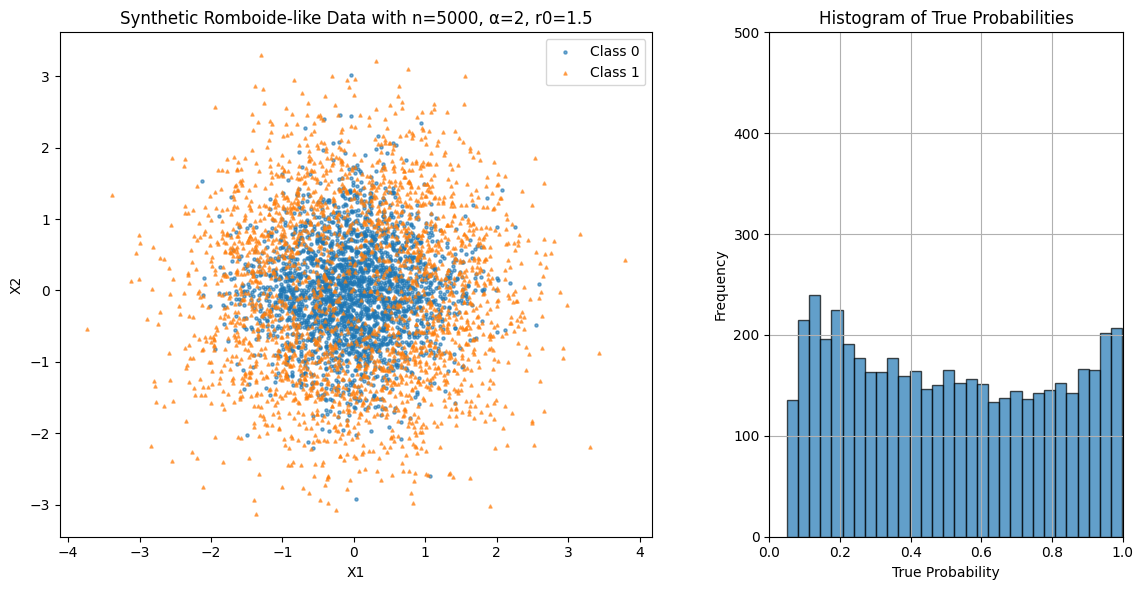

Proportion of positive samples: 0.50


In [6]:
# 1) PARAMETERS
n = 5000
alpha = 2 # controls sharpness of the circle boundary
r0 = 1.5   # target radius
# alpha = 5
# r0 = 1.0   # target radius
# 2) SIMULATE FEATURES from a normal distribution
np.random.seed(0)  # for reproducibility
X1 = np.random.normal(0, 1, n)
X2 = np.random.normal(0, 1, n)
r2 = np.abs(X1) + np.abs(X2)  # r^2 = |X1| + |X2|

# 3) DEFINE TRUE PROBABILITIES USING A SIGMOID ON r^2 - r0
p = 1 / (1 + np.exp(-alpha * (r2 - r0)))

# 4) SAMPLE OUTCOME y ~ Bernoulli(p)
y = np.random.binomial(1, p)


# Subplots for the scatter plot and the histogram
fig = plt.figure(figsize=(12, 6))
gs = GridSpec(1, 2, width_ratios=[2, 1])

# a) SCATTER PLOT
classes = np.unique(y)
ax1 = fig.add_subplot(gs[0])
ax1.set_title(f'Synthetic Romboide-like Data with n={n}, α={alpha}, r0={r0}')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
# Plot the points with different markers for each class
for cls, marker in zip(classes, ['o', '^']):
    ax1.scatter(
        X1[y==cls], 
        X2[y==cls], 
        alpha=0.6, 
        marker=marker, 
        label=f'Class {int(cls)}',
        s=5
    )
ax1.legend()

# b) HISTOGRAM OF PROBABILITIES
ax2 = fig.add_subplot(gs[1])
ax2.set_title('Histogram of True Probabilities')
ax2.set_xlabel('True Probability')
ax2.set_ylabel('Frequency')
ax2.hist(p, bins=30, alpha=0.7, edgecolor='black')
ax2.grid()
# Show the plots in equal proportions without blank spaces
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 500)
ax2.set_aspect('auto', adjustable='box')
ax1.set_aspect('equal', adjustable='box')
plt.tight_layout()
plt.show()

# Proportion of positive samples
positive_proportion = np.mean(y)
print(f"Proportion of positive samples: {positive_proportion:.2f}")

In [7]:
# Full X dataset
X = np.column_stack((X1, X2))

# Separate in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)  

In [8]:
# Testing the tree construction
features = [0,1]

tree = grow_spline_tree(X_train, y_train, features, max_depth=6, min_samples_leaf=10, purity_threshold=0.95, verbose=True)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

In [9]:
# Testing the prediction function
predictions = predict(X_test, tree)
# Accuracy of the predictions
accuracy = np.mean(predictions == y_test)
print(f"Accuracy of the predictions: {accuracy:.2f}")

Accuracy of the predictions: 0.67


In [10]:
# Grid search for hyperparameters
from sklearn.model_selection import ParameterGrid

# Example grid search parameters
param_grid = {
    'max_depth': [3, 4, 5, 6],
    'min_samples_leaf': [5, 10, 20],
    'purity_threshold': [0.75, 0.8, 0.9, 0.95, 0.99]
}

grid = ParameterGrid(param_grid)
best_acc = -np.inf
best_tree = None
best_params = None

for params in grid:
    tree = grow_spline_tree(X_train, y_train, features, max_depth=params['max_depth'],
                            min_samples_leaf=params['min_samples_leaf'],
                            purity_threshold=params['purity_threshold'], verbose=False)
    
    predictions = predict(X_test, tree)
    accuracy = np.mean(predictions == y_test)
    
    if accuracy > best_acc:
        best_acc = accuracy
        best_tree = tree
        best_params = params

print(f"Best accuracy: {best_acc:.4f} with parameters: {best_params}")

Best accuracy: 0.6687 with parameters: {'max_depth': 6, 'min_samples_leaf': 10, 'purity_threshold': 0.75}


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as mlines


def plot_custom_tree(node, depth=0, pos_x=0.5, pos_y=1.0, dx=0.2, dy=0.15, ax=None, parent_pos=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 15))
        ax.set_axis_off()
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        plot_custom_tree(node, depth, pos_x, pos_y, dx, dy, ax)
        plt.show()
        return

    # Línea desde el padre
    if parent_pos is not None:
        ax.add_line(mlines.Line2D([parent_pos[0], pos_x], [parent_pos[1], pos_y], color='black'))

    # Nodo
    if node.is_leaf:
        label = (
        f"Leaf\n"
        f"Predict: {node.prediction}\n"
        f"value = {node.value.tolist()}\n"
        f"n = {node.n_samples}"
        )
        color = 'lightgreen'
    else:
        label = (
        f"[{node.feature} ≤ {node.tau:.2f}]\n"
        f"depth = {depth} | n = {node.n_samples}\n"
        f"value = {node.value.tolist()}"
    )
        color = 'lightblue'

    bbox = dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor=color)
    ax.text(pos_x, pos_y, label, ha='center', va='center', bbox=bbox, fontsize=10)

    # Recursión
    if not node.is_leaf:
        dx_child = dx * 0.8  # más cerrado en profundidad
        dy_child = dy
        plot_custom_tree(node.left, depth + 1, pos_x - dx, pos_y - dy, dx_child, dy_child, ax, (pos_x, pos_y))
        plot_custom_tree(node.right, depth + 1, pos_x + dx, pos_y - dy, dx_child, dy_child, ax, (pos_x, pos_y))


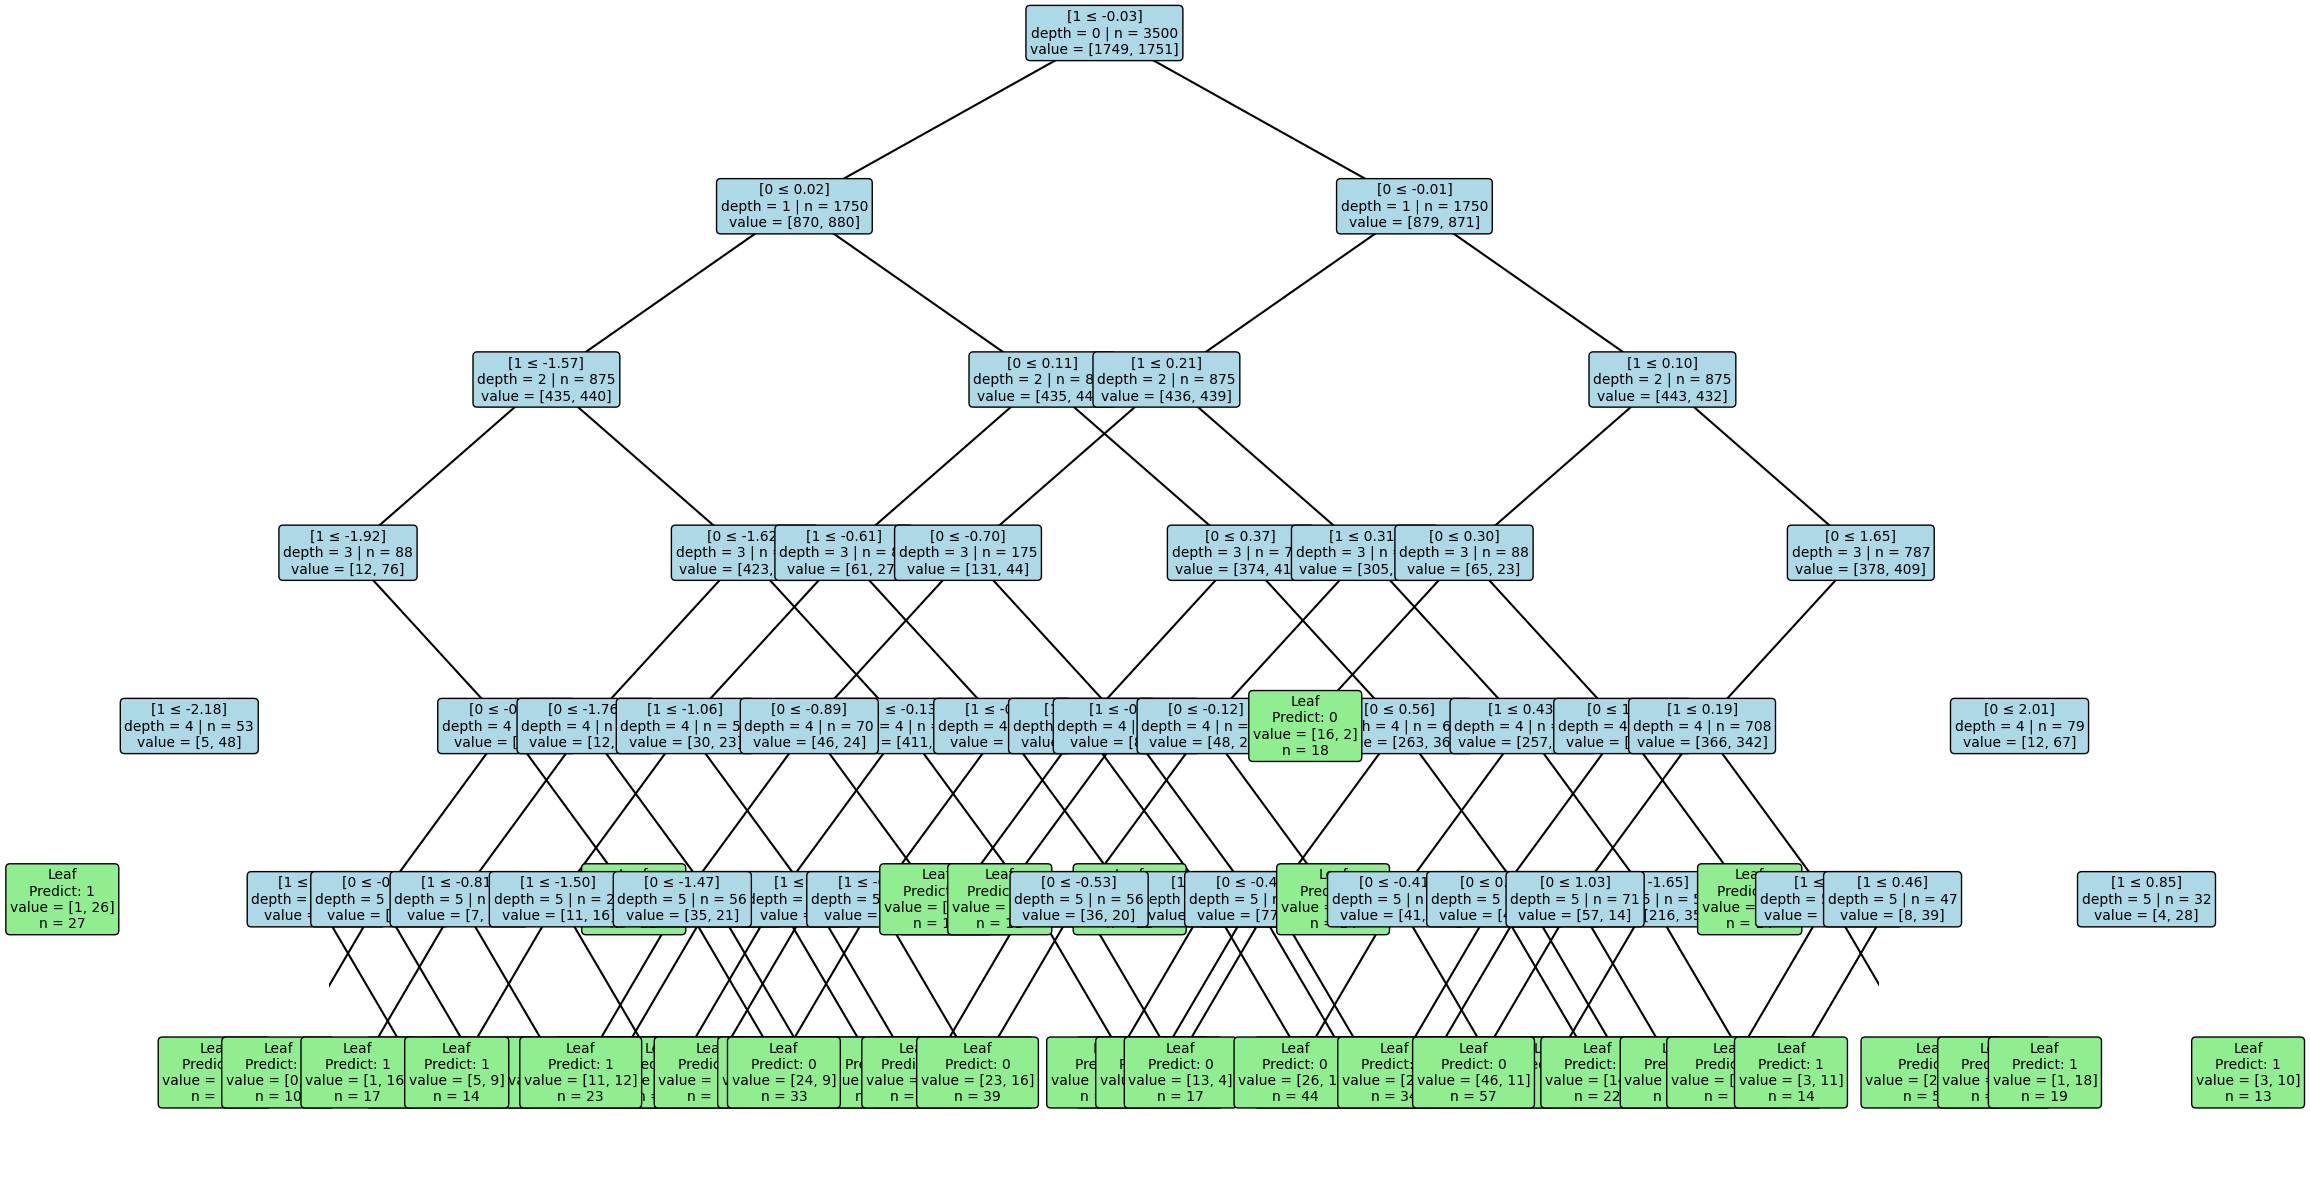

In [11]:
plot_custom_tree(tree)

In [12]:
def plot_decision_surface_from_custom_tree(
    clf_tree,
    X,
    feature_pair,
    y=None,
    fixed_vals=None,
    grid_steps=200,
    cmap='RdYlBu',
    ax=None,
    title='Decision surface (custom spline tree)',
    plot_splits=False
):
    """
    Plots 2D decision surface and optionally split lines for a custom spline-based decision tree.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    i, j = feature_pair

    x_min, x_max = X[:, i].min(), X[:, i].max()
    y_min, y_max = X[:, j].min(), X[:, j].max()

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )

    if fixed_vals is None:
        fixed_vals = X.mean(axis=0)

    base = np.tile(fixed_vals, (xx.size, 1))
    base[:, i] = xx.ravel()
    base[:, j] = yy.ravel()

    Z = predict(base, clf_tree).reshape(xx.shape)

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    contour = ax.contourf(xx, yy, Z, cmap=cmap, alpha=0.6)

    if y is not None:
        norm = contour.norm
        cmap_used = contour.cmap
        for cls in np.unique(y):
            mask = (y == cls)
            color = cmap_used(norm(cls))
            ax.scatter(
                X[mask, i],
                X[mask, j],
                color=color,
                edgecolor='k',
                s=30,
                label=f'class {cls}'
            )
        ax.legend(loc='lower right')

    ax.set_xlabel(f'Feature {i}')
    ax.set_ylabel(f'Feature {j}')
    ax.set_title(title)

    # Plot split lines if requested
    if plot_splits:
        def add_splits(node):
            if node.is_leaf:
                return
            if node.feature == i:
                ax.axvline(x=node.tau, color='black', linestyle='--', linewidth=1)
            elif node.feature == j:
                ax.axhline(y=node.tau, color='black', linestyle='--', linewidth=1)
            add_splits(node.left)
            add_splits(node.right)

        add_splits(clf_tree)

    return ax, contour



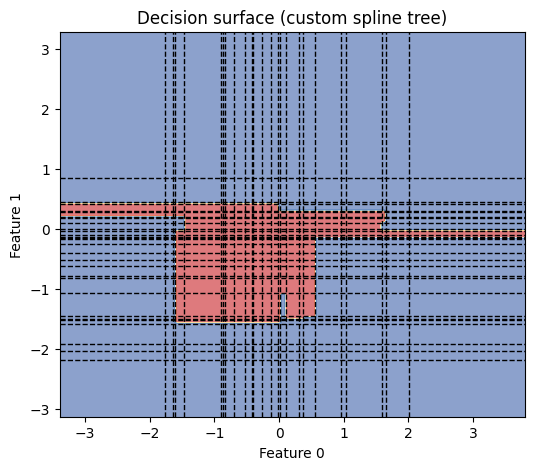

In [13]:

plot_decision_surface_from_custom_tree(tree, X_train, feature_pair=(0, 1), plot_splits=True)
plt.show()


In [14]:
# Predict probabilities functions
def predict_proba_single(x, node):
    """
    Predicts class probabilities for a single observation x (as a pandas Series)
    using the decision tree rooted at `node`.
    """
    while not node.is_leaf:
        if x[node.feature] <= node.tau:
            node = node.left
        else:
            node = node.right

    value = node.value
    total = value.sum()
    proba = value / total
    return proba

def predict_proba(X, root):
    """
    Predicts class probabilities for a DataFrame X using the tree rooted at `root`.
    Returns a numpy array of probabilities.
    """
    return np.array([predict_proba_single(row, root) for row in X])

In [15]:
def plot_probability_surface_tree(
    clf_tree,
    X,
    feature_pair,
    prob_class=1,
    fixed_vals=None,
    grid_steps=200,
    cmap='RdYlBu',
    ax=None,
    title='Predicted probability surface',
    plot_splits=False
):
    """
    Plots a 2D probability surface for a custom decision tree,
    showing P(y = prob_class) ∈ [0,1], with optional split lines.
    """
    import numpy as np
    import matplotlib.pyplot as plt

    i, j = feature_pair

    # 1) Build grid
    x_min, x_max = X[:, i].min(), X[:, i].max()
    y_min, y_max = X[:, j].min(), X[:, j].max()
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )

    # 2) Fill unused features with fixed values
    if fixed_vals is None:
        fixed_vals = X.mean(axis=0)
    base = np.tile(fixed_vals, (xx.size, 1))
    base[:, i] = xx.ravel()
    base[:, j] = yy.ravel()

    # 3) Predict probabilities
    probs = predict_proba(base, clf_tree)[:, prob_class].reshape(xx.shape)

    # 4) Plot probability surface
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))
    levels = np.linspace(0, 1, 51)
    contour = ax.contourf(
        xx, yy, probs,
        levels=levels,
        cmap=cmap,
        vmin=0, vmax=1,
        alpha=0.8
    )
    plt.colorbar(contour, ax=ax, label=f'P(y={prob_class})')

    # 5) Overlay points colored by their predicted prob
    point_probs = predict_proba(X, clf_tree)[:, prob_class]
    ax.scatter(
        X[:, i], X[:, j],
        c=point_probs,
        cmap=cmap,
        vmin=0, vmax=1,
        edgecolor='k',
        s=20,
        alpha=0.6
    )

    # 6) Labels and title
    ax.set_xlabel(f'Feature {i}')
    ax.set_ylabel(f'Feature {j}')
    ax.set_title(title)

    # 7) Optional: Draw split lines
    if plot_splits:
        def draw_splits(node):
            if node.is_leaf:
                return
            if node.feature == i:
                ax.axvline(x=node.tau, color='black', linestyle='--', linewidth=1)
            elif node.feature == j:
                ax.axhline(y=node.tau, color='black', linestyle='--', linewidth=1)
            draw_splits(node.left)
            draw_splits(node.right)

        draw_splits(clf_tree)

    return ax, contour


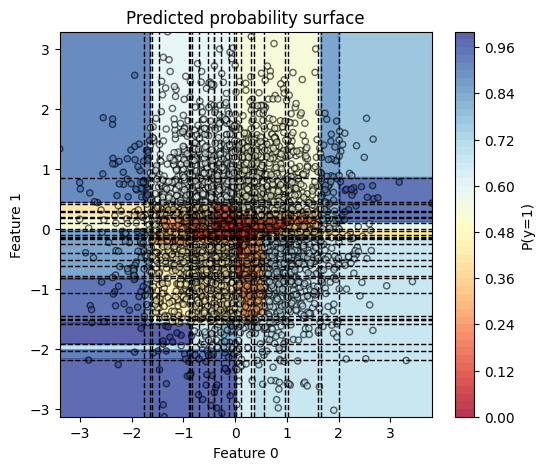

In [16]:
plot_probability_surface_tree(tree, X_train, feature_pair=(0, 1), plot_splits=True)
plt.show()

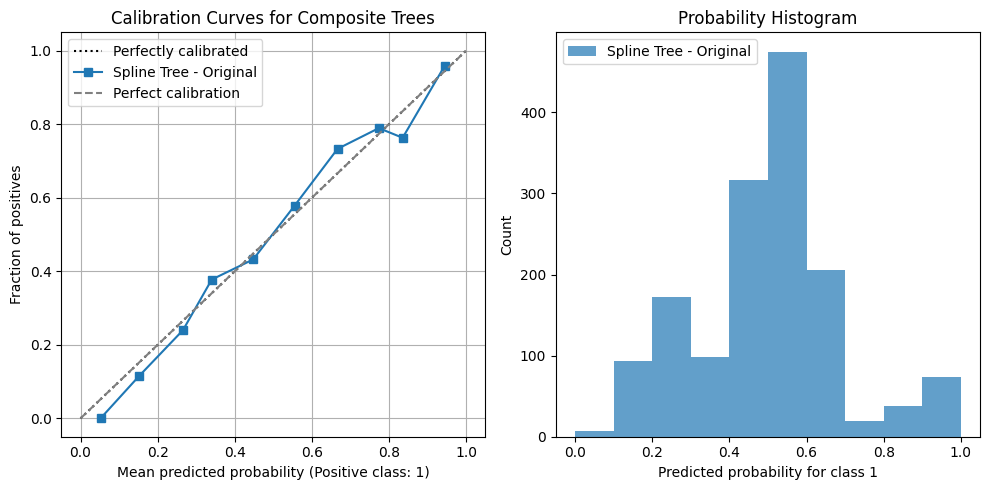

In [17]:
from sklearn.calibration import CalibrationDisplay
from matplotlib.gridspec import GridSpec


fig = plt.figure(figsize=(10, 5))
gs = GridSpec(1, 2, figure=fig)

ax_curve = fig.add_subplot(gs[0])
ax_hist1 = fig.add_subplot(gs[1])

colors = plt.get_cmap("tab10")

# --- Calibration curve ---
n_bins = 10
proba_o = predict_proba(X_test, tree)[:, 1]
    

CalibrationDisplay.from_predictions(
    y_test, proba_o, n_bins=n_bins,
    name=f"Spline Tree - Original",
    ax=ax_curve, color=colors(2 * 0)
)
    

ax_curve.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax_curve.set_title("Calibration Curves for Composite Trees")
ax_curve.set_xlabel("Mean predicted probability (Positive class: 1)")
ax_curve.set_ylabel("Fraction of positives")
ax_curve.grid(True)
ax_curve.legend(loc='best')

# --- First histogram (model 0 original vs extended) ---
ax_hist1.hist(proba_o, bins=n_bins, range=(0, 1), alpha=0.7, color=colors(0), label=f"Spline Tree - Original")
ax_hist1.set_title(f"Probability Histogram")
ax_hist1.set_xlabel("Predicted probability for class 1")
ax_hist1.set_ylabel("Count")
ax_hist1.legend()


fig.tight_layout()
plt.show()

In [42]:
def plot_pred_vs_true(
    models: dict,
    p_true: np.ndarray,
    X_test: np.ndarray,
    model_type: str = 'tree',
    orig_cols: int = 2,
    figsize: tuple = (12, 5)
):
    """
    models: 
      - if model_type=='tree': { name: clf, ... }
      - if model_type=='lmt' : { name: (clf, nodes), ... }
      - if model_type=='logitboost': { name: (learners, J), ... }
      - if model_type=='composite': { name: (clf, nodes), ... }
      - if model_type=='spline_tree': { name: clf, ... }
      - if model_type=='spline_lmt': { name: (clf, nodes), ... }
    p_true: array of true probabilities, shape (n_samples,)
    X_test: feature matrix, shape (n_samples, n_features)
    model_type: 'tree', 'lmt' or 'logitboost'
    orig_cols: how many cols from X_test to use for models tagged as '(orig)'
    """
    import matplotlib.cm as cm
    colors = cm.get_cmap("tab10")
    markers = ['o', '^', 's', 'v', '<', '>', 'X', 'D']

    # Create shared subplots for all models
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    for idx, ((name, val), marker) in enumerate(zip(models.items(), markers)):
        # Get X subset based on model name
        X_in = X_test[:, :orig_cols] if '(orig)' in name else X_test

        # Predict based on model type
        if model_type == 'tree':
            clf = val
            y_pred = clf.predict_proba(X_in)[:, 1]
        elif model_type == 'lmt':
            clf, nodes = val
            y_pred = lmt.predict_proba_lmt(X_in, clf, nodes)
        elif model_type == 'logitboost':
            learners, J = val
            y_pred = logitboost.logitboost_predict_proba(X_in, learners, J)[:, 1]
        elif model_type == 'composite':
            clf, nodes = val
            y_pred = composite_tree.predict_proba_composite_lmt(X_in, clf, nodes)[:, 1]
        elif model_type == 'spline_tree':
            clf = val
            y_pred = predict_proba(X_in, clf)[:, 1]
        elif model_type == 'spline_lmt':
            clf, nodes = val
            y_pred = predict_proba_lmt_custom(X_in, clf, nodes)[:, 1]
        else:
            raise ValueError("model_type must be 'tree', 'lmt', or 'logitboost'")

        # Scatter plot
        ax1.scatter(
            p_true, y_pred,
            alpha=0.5, s=20,
            marker=marker,
            label=name,
            color=colors(idx % 10)
        )

    # Perfect calibration line
    ax1.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax1.set_xlim([0, 1])
    ax1.set_ylim([0, 1])
    ax1.set_xlabel("True probability $p_i$")
    ax1.set_ylabel("Predicted probability $\hat p_i$")
    ax1.set_title("Predicted vs True Probabilities")
    ax1.grid(True, linestyle='--', alpha=0.5)
    ax1.legend(loc='lower right', fontsize='small')

    # Histogram of true probabilities
    ax2.hist(p_true, bins=20, color=colors(2), alpha=0.7)
    ax2.set_title("Histogram of True Probabilities")
    ax2.set_xlabel("True probability $p_i$")
    ax2.set_ylabel("Count")
    ax2.grid(True)

    plt.tight_layout()
    plt.show()


C:\Users\allis\AppData\Local\Temp\ipykernel_12588\2925056920.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


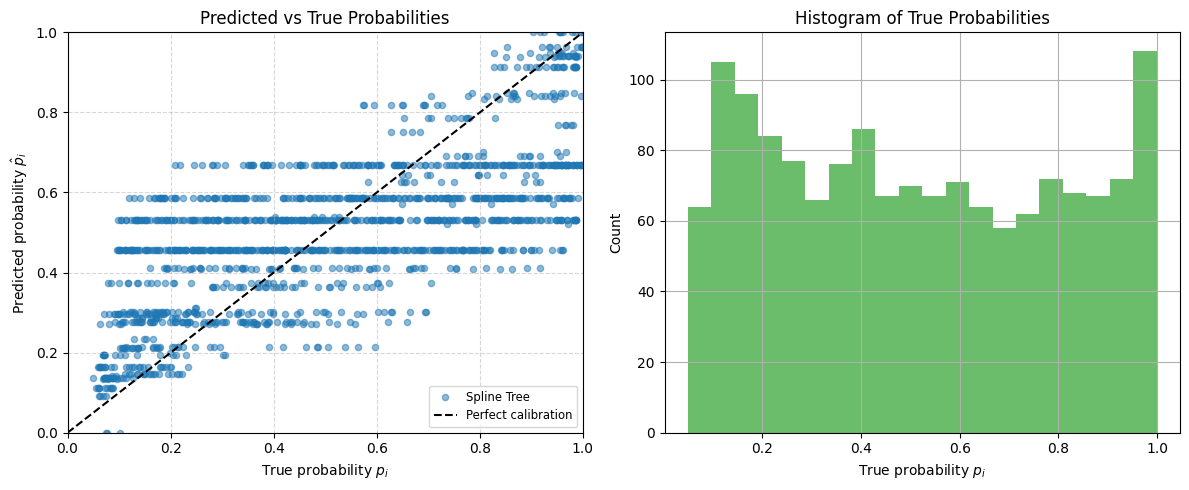

In [21]:
from scipy.special import expit

p_true = expit(alpha * (np.abs(X_test[:, 0]) + np.abs(X_test[:, 1]) - r0))
models = {
    'Spline Tree': tree
}

plot_pred_vs_true(models, p_true, X_test, model_type='spline_tree', orig_cols=2, figsize=(12, 5))
plt.show()

# LMT fitting (Version 2)

In [22]:
def fit_logistic_model_tree_custom(
    X, y,
    features,
    max_depth=3,
    min_samples_leaf=10,
    purity_threshold=0.95,
    verbose=False,
    lb_n_estimators=200,
    lb_eps=1e-5,
    lb_cv_splits=5,
    lb_random_state=0
):
    """
    Entrena un árbol custom con LogitBoost en cada nodo (raíz con SimpleLogistic).

    Parameters
    ----------
    X : ndarray (n_samples, n_features)
    y : ndarray (n_samples,)
    features : list of feature indices
    max_depth : int
    min_samples_leaf : int
    purity_threshold : float
    verbose : bool
    lb_* : parámetros para LogitBoost

    Returns
    -------
    root_node : raíz del árbol (TreeNode)
    node_models : dict con node_id -> {learners, J, M_star, cv_errors}
    """

    node_models = {}
    node_counter = [0]  # contador mutable para asignar node_id

    # Paso 1: construir el árbol base (con node_id)
    root_node = grow_spline_tree(
        X, y,
        features=features,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        purity_threshold=purity_threshold,
        verbose=verbose,
        node_id_counter=node_counter
    )

    # Paso 2: Entrenar modelo en la raíz con validación cruzada (SimpleLogistic)
    learners_root, J_root, M_star, cv_errs = logitboost.simple_logistic_fit(
        X, y,
        n_estimators=lb_n_estimators,
        eps=lb_eps,
        cv_splits=lb_cv_splits,
        warm_start=None,
        random_state=lb_random_state
    )

    # Guardar modelo de la raíz
    node_models[root_node.node_id] = {
        'learners': learners_root,
        'J': J_root,
        'M_star': M_star,
        'cv_errors': cv_errs
    }

    # Paso 3: función recursiva para entrenar hijos
    def recurse(node, X_sub, y_sub, warm_start):
        if node.is_leaf:
            return

        # Dividir datos según el split del nodo actual
        mask_left = X_sub[:, node.feature] <= node.tau
        mask_right = ~mask_left

        for child_node, child_mask in zip([node.left, node.right], [mask_left, mask_right]):
            X_child = X_sub[child_mask]
            y_child = y_sub[child_mask]

            # Entrenar LogitBoost clásico con M_star y warm_start
            learners, J = logitboost.logitboost_fit(
                X_child, y_child,
                n_estimators=M_star,
                eps=lb_eps,
                warm_start=warm_start
            )

            node_models[child_node.node_id] = {
                'learners': learners,
                'J': J,
                'M_star': M_star,
                'cv_errors': None
            }

            # Recursión
            recurse(child_node, X_child, y_child, warm_start=(learners, J))

    # Paso 4: comenzar desde la raíz
    recurse(root_node, X, y, warm_start=(learners_root, J_root))

    return root_node, node_models





In [23]:
features = [0, 1]  # columnas a usar

tree, node_models = fit_logistic_model_tree_custom(
    X_train, y_train,
    features=features,
    max_depth=6,
    min_samples_leaf=10,
    purity_threshold=0.95,
    verbose=False
)


In [24]:
# print the different values for M_star in node_models
print("Different M_star values in node_models:")
for node_id, model in node_models.items():
    print(f"Node {node_id}: M_star = {model['M_star']}")
# node_models

Different M_star values in node_models:
Node 104: M_star = 3
Node 54: M_star = 3
Node 26: M_star = 3
Node 10: M_star = 3
Node 4: M_star = 3
Node 0: M_star = 3
Node 3: M_star = 3
Node 1: M_star = 3
Node 2: M_star = 3
Node 9: M_star = 3
Node 7: M_star = 3
Node 5: M_star = 3
Node 6: M_star = 3
Node 8: M_star = 3
Node 25: M_star = 3
Node 17: M_star = 3
Node 13: M_star = 3
Node 11: M_star = 3
Node 12: M_star = 3
Node 16: M_star = 3
Node 14: M_star = 3
Node 15: M_star = 3
Node 24: M_star = 3
Node 20: M_star = 3
Node 18: M_star = 3
Node 19: M_star = 3
Node 23: M_star = 3
Node 21: M_star = 3
Node 22: M_star = 3
Node 53: M_star = 3
Node 39: M_star = 3
Node 33: M_star = 3
Node 29: M_star = 3
Node 27: M_star = 3
Node 28: M_star = 3
Node 32: M_star = 3
Node 30: M_star = 3
Node 31: M_star = 3
Node 38: M_star = 3
Node 36: M_star = 3
Node 34: M_star = 3
Node 35: M_star = 3
Node 37: M_star = 3
Node 52: M_star = 3
Node 44: M_star = 3
Node 40: M_star = 3
Node 43: M_star = 3
Node 41: M_star = 3
Node 42: 

In [25]:
# Predicting function for the custom tree with LogitBoost models
def predict_lmt_custom(X, root_node, node_models):
    """
    Predict class labels for a custom Logistic Model Tree.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
        Test samples.
    root_node : TreeNode
        Root of the custom decision tree.
    node_models : dict
        Maps node_id -> { 'learners': [...], 'J': int, ... }.

    Returns
    -------
    preds : ndarray of shape (n_samples,)
        Predicted class indices.
    """
    preds = np.empty(len(X), dtype=int)

    for i, x_i in enumerate(X):
        node = root_node
        while not node.is_leaf:
            if x_i[node.feature] <= node.tau:
                node = node.left
            else:
                node = node.right

        node_id = node.node_id
        learners = node_models[node_id]['learners']
        J = node_models[node_id]['J']
        p = logitboost.logitboost_predict(x_i.reshape(1, -1), learners, J)
        preds[i] = p[0]

    return preds



def predict_proba_lmt_custom(X, root_node, node_models):
    """
    Predict probability distributions for a custom LMT.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
    root_node : TreeNode
        Root of the custom decision tree.
    node_models : dict mapping node_id -> { 'learners': [...], 'J': int, ... }

    Returns
    -------
    proba_matrix : ndarray of shape (n_samples, J_global)
        Predicted class probabilities for each sample.
    """
    J_global = max(m['J'] for m in node_models.values())
    proba_matrix = np.zeros((len(X), J_global), dtype=float)

    for i, x_i in enumerate(X):
        node = root_node
        while not node.is_leaf:
            if x_i[node.feature] <= node.tau:
                node = node.left
            else:
                node = node.right

        node_id = node.node_id
        learners = node_models[node_id]['learners']
        J = node_models[node_id]['J']
        p = logitboost.logitboost_predict_proba(x_i.reshape(1, -1), learners, J)
        proba_matrix[i, :J] = p[0]

    return proba_matrix


In [26]:
y_pred_lmt = predict_lmt_custom(X_test, tree, node_models)
accuracy_lmt = np.mean(y_pred_lmt == y_test)
print(f"Accuracy of LMT predictions: {accuracy_lmt:.2f}")

print('Available node ids in node_models:', list(node_models.keys()))

Accuracy of LMT predictions: 0.69
Available node ids in node_models: [104, 54, 26, 10, 4, 0, 3, 1, 2, 9, 7, 5, 6, 8, 25, 17, 13, 11, 12, 16, 14, 15, 24, 20, 18, 19, 23, 21, 22, 53, 39, 33, 29, 27, 28, 32, 30, 31, 38, 36, 34, 35, 37, 52, 44, 40, 43, 41, 42, 51, 47, 45, 46, 50, 48, 49, 103, 79, 65, 59, 57, 55, 56, 58, 64, 60, 63, 61, 62, 78, 70, 68, 66, 67, 69, 77, 73, 71, 72, 76, 74, 75, 102, 86, 80, 85, 83, 81, 82, 84, 101, 93, 89, 87, 88, 92, 90, 91, 100, 96, 94, 95, 99, 97, 98]


In [125]:
def compute_tree_depth(node):
    if node.is_leaf:
        return 1
    return 1 + max(compute_tree_depth(node.left), compute_tree_depth(node.right))

def plot_custom_tree_with_models(
    node,
    node_models,
    X,
    title="Custom LMT with LogitBoost Models",
    model_threshold=1e-6,
    show_internal=False,
    depth=0,
    pos_x=0.5,
    pos_y=0.95,
    dx=0.2,
    dy=0.15,
    ax=None,
    parent_pos=None
):
    """
    Plots a custom decision tree (built from LeafNode / DecisionNode)
    and overlays the logitboost model formulas in each leaf (or optionally in all nodes).
    """
    if ax is None:
        depth_max = compute_tree_depth(node)
        fig_height = 1.5 + depth_max * dy * 5  # altura proporcional
        fig, ax = plt.subplots(figsize=(20, fig_height))
        ax.set_axis_off()
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1.05)  # deja un pequeño margen para el título
        ax.set_title(title, fontsize=14, y=1.02)  # empuja título hacia arriba
        plot_custom_tree_with_models(node, node_models, X, title, model_threshold, show_internal, depth, pos_x, pos_y, dx, dy, ax)
        plt.tight_layout()
        plt.show()
        return

    # Draw edge from parent
    if parent_pos is not None:
        ax.add_line(mlines.Line2D([parent_pos[0], pos_x], [parent_pos[1], pos_y], color='black'))

    # Get linear model if available
    model_str = ""
    if node.node_id in node_models:
        mdl = node_models[node.node_id]
        intercepts, coefs = logitboost.extract_linear_models(mdl['learners'], mdl['J'], X.shape[1])
        lines = []
        for j in range(mdl['J']):
            b = intercepts[j]
            parts = [f"F{j}(x)={b:.2f}"]
            for k in range(X.shape[1]):
                a = coefs[j, k]
                if abs(a) > model_threshold:
                    parts.append(f"{'+' if a >= 0 else '-'}{abs(a):.2f}*x[{k}]")
            lines.append(" ".join(parts))
        model_str = "\n" + "\n".join(lines)

    # Node label
    if node.is_leaf:
        label = (
            f"Leaf\n"
            f"Predict: {node.prediction}\n"
            f"value = {node.value.tolist()}\n"
            f"n = {node.n_samples}"
        )
        if show_internal or True:
            label += model_str
        color = 'lightgreen'
    else:
        label = (
            f"[x[{node.feature}] ≤ {node.tau:.2f}]\n"
            f"depth = {depth} | n = {node.n_samples}\n"
            f"value = {node.value.tolist()}"
        )
        if show_internal:
            label += model_str
        color = 'lightblue'

    # Draw the node
    bbox = dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor=color)
    ax.text(pos_x, pos_y, label, ha='center', va='center', bbox=bbox, fontsize=10)

    # Recursive calls
    if not node.is_leaf:
        dx_child = dx * 0.8
        dy_child = dy
        plot_custom_tree_with_models(node.left, node_models, X, title, model_threshold, show_internal, depth + 1,
                                     pos_x - dx, pos_y - dy, dx_child, dy_child, ax, (pos_x, pos_y))
        plot_custom_tree_with_models(node.right, node_models, X, title, model_threshold, show_internal, depth + 1,
                                     pos_x + dx, pos_y - dy, dx_child, dy_child, ax, (pos_x, pos_y))


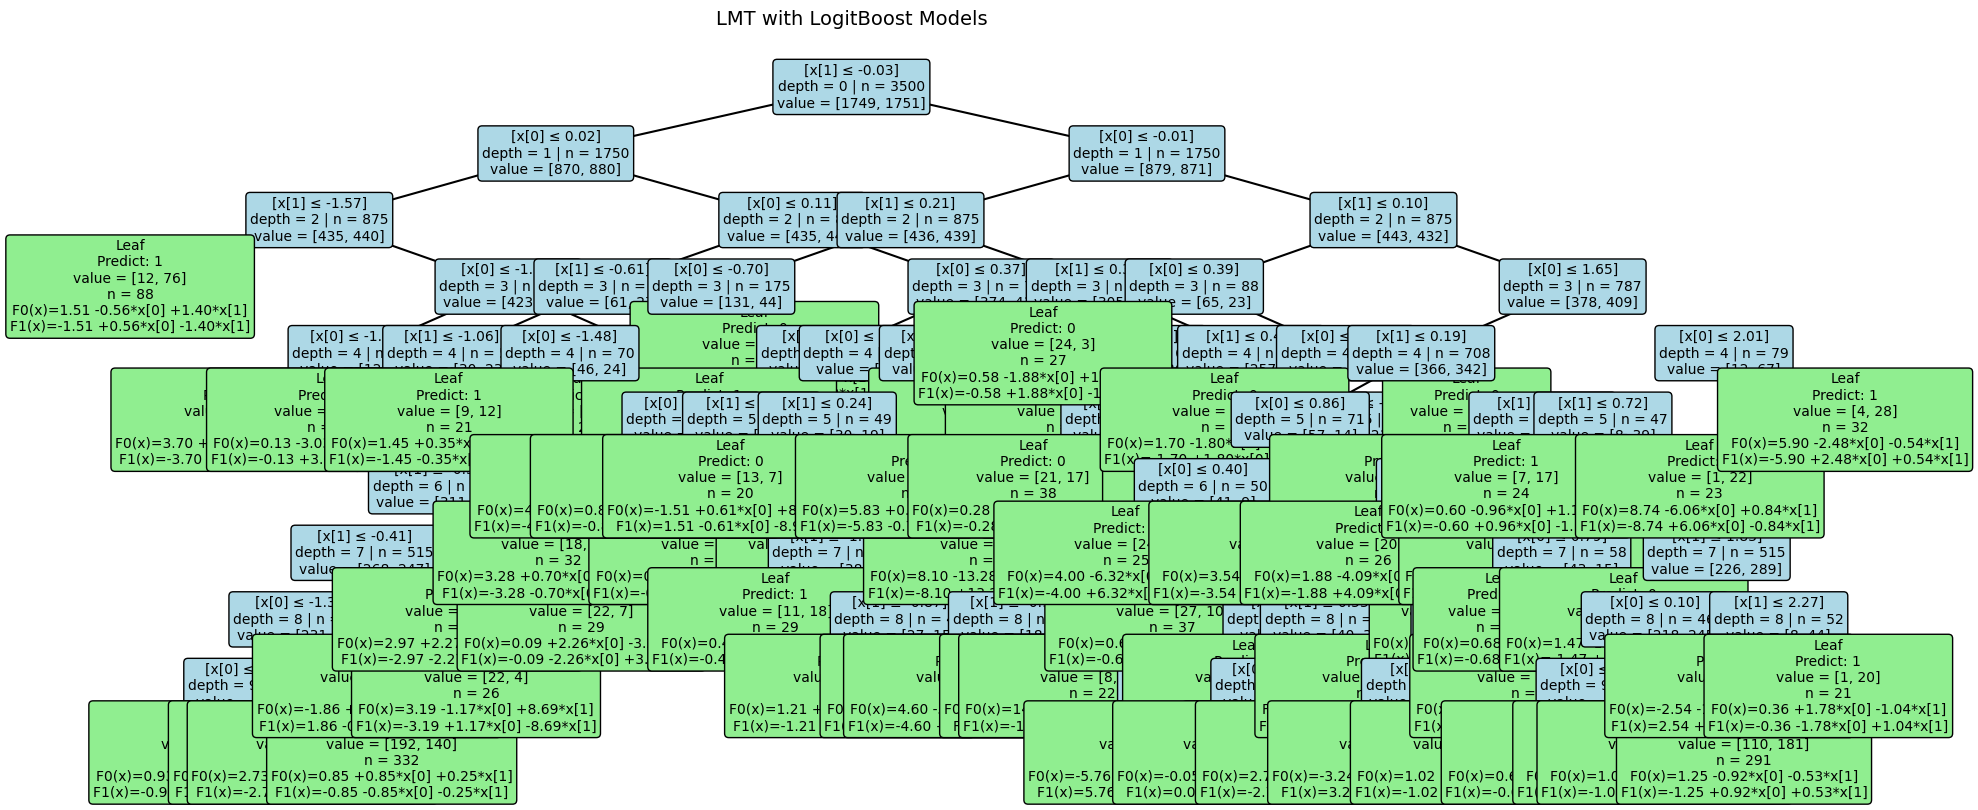

In [114]:
plot_custom_tree_with_models(
    tree,           # from fit_logistic_model_tree_custom
    node_models,         # from fit_logistic_model_tree_custom
    X_train,                   # your original feature matrix
    title="LMT with LogitBoost Models",
    show_internal=False  # set True if you also want models in internal nodes
)


In [29]:
def plot_decision_regions_custom_tree(
    X,
    y,
    root_node,
    node_models,
    feature_pair=(0, 1),
    show_scatter=True,
    fill_value="mean",  # "mean" | "median" | float
    grid_steps=200,
    cmap='RdYlBu',
    ax=None,
    title="Decision regions (Custom LMT)"
):
    """
    Plots the 2D decision regions of a custom Logistic Model Tree using its predictions.

    Parameters
    ----------
    X : ndarray (n_samples, D)
        Full dataset.
    y : ndarray (n_samples,)
        True labels (0 … J-1), used for overlay and J=number of classes.
    root_node : custom tree root node
        The root of the DecisionNode / LeafNode structure.
    node_models : dict
        Mapping node_id -> {'learners', 'J', ...}.
    feature_pair : tuple(int i, int j)
        Features to plot on x/y axes.
    fill_value : str | float
        How to fill remaining dimensions.
    grid_steps : int
        Grid resolution.
    cmap : str or Colormap
        Matplotlib colormap.
    ax : matplotlib axis
        Optional axis for subplotting.
    title : str
    """
    i, j = feature_pair
    D = X.shape[1]
    classes = np.unique(y)
    J = len(classes)

    # 1) Grid in 2D
    x_min, x_max = X[:, i].min() - 1, X[:, i].max() + 1
    y_min, y_max = X[:, j].min() - 1, X[:, j].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )
    grid_pts = np.c_[xx.ravel(), yy.ravel()]
    n_grid = grid_pts.shape[0]

    # 2) Fill rest of features
    if fill_value == "mean":
        default = X.mean(axis=0)
    elif fill_value == "median":
        default = np.median(X, axis=0)
    else:
        default = np.full(D, float(fill_value))

    X_grid = np.tile(default, (n_grid, 1))
    X_grid[:, i] = grid_pts[:, 0]
    X_grid[:, j] = grid_pts[:, 1]

    # 3) Predict using your custom tree
    Z_flat = predict_lmt_custom(X_grid, root_node, node_models)
    Z = Z_flat.reshape(xx.shape)

    # 4) Plot regions
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    levels = np.arange(J + 1) - 0.5
    cf = ax.contourf(xx, yy, Z, levels=levels, cmap=cmap, alpha=0.3)

    # 5) Overlay scatter
    if show_scatter:
        norm = cf.norm
        cmap_used = cf.cmap
        for cls in classes:
            mask = (y == cls)
            color = cmap_used(norm(cls))
            sc = ax.scatter(
                X[mask, i], X[mask, j],
                c=[cls] * np.sum(mask),
                cmap=cmap_used,
                norm=norm,
                s=20,
                edgecolor='k',
                linewidth=0.3
            )
        handles, _ = sc.legend_elements()
        ax.legend(handles, [f"class {c}" for c in classes], loc="lower right")

    ax.set_xlabel(f"Feature {i}")
    ax.set_ylabel(f"Feature {j}")
    ax.set_title(title)

    return ax, cf


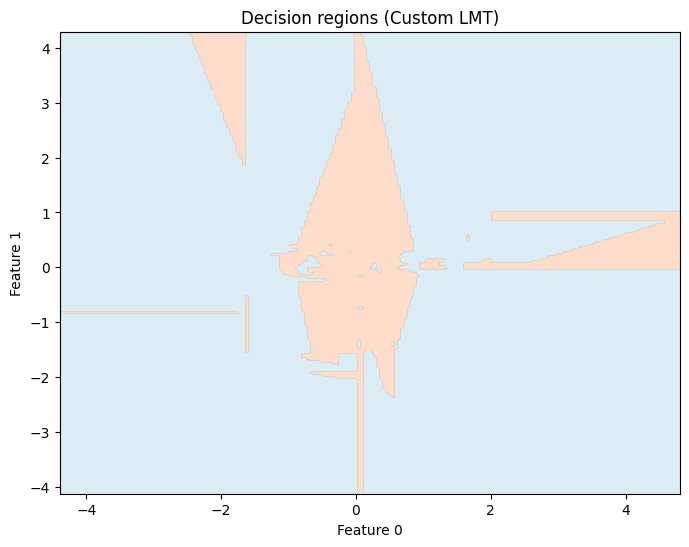

In [30]:
plot_decision_regions_custom_tree(
    X_train, y_train, tree, node_models, show_scatter=False)
plt.show()

In [31]:
def plot_probability_surface_custom_tree(
    root_node,
    node_models,
    X,
    feature_pair=(0,1),
    prob_class=1,
    fixed_vals=None,
    grid_steps=200,
    cmap='RdYlBu',
    ax=None,
    title='Predicted probability surface (Custom LMT)',
    show_scatter=True
):
    """
    Plots a 2D probability surface from your custom Logistic Model Tree (LMT),
    colouring each point by P(y = prob_class), and overlays the training points
    coloured by their own predicted probability.

    Parameters
    ----------
    root_node : root of the custom tree (from fit_logistic_model_tree_custom)
    node_models : dict mapping node_id to trained LogitBoost models
    X : array-like, shape (n_samples, n_features)
        Training data
    feature_pair : tuple of two ints (i, j)
        Indices of features to plot
    prob_class : int, default=1
        Class index to show probability surface for
    fixed_vals : array-like (n_features,), optional
        Default values for non-displayed dimensions
    grid_steps : int
        Grid resolution
    cmap : str or colormap
    ax : matplotlib Axes
    title : str
    show_scatter : bool
        Whether to overlay the training points
    """
    i, j = feature_pair

    # 1) Build 2D grid
    x_min, x_max = X[:, i].min(), X[:, i].max()
    y_min, y_max = X[:, j].min(), X[:, j].max()
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_steps),
        np.linspace(y_min, y_max, grid_steps)
    )

    # 2) Lift grid to full D-dimensional space
    if fixed_vals is None:
        fixed_vals = X.mean(axis=0)
    base = np.tile(fixed_vals, (xx.size, 1))
    base[:, i] = xx.ravel()
    base[:, j] = yy.ravel()

    # 3) Predict probabilities using your tree
    Z_flat = predict_proba_lmt_custom(base, root_node, node_models)[:, prob_class]
    Z_flat = np.clip(Z_flat, 0, 1)
    Z = Z_flat.reshape(xx.shape)

    # 4) Plot surface
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 5))

    levels = np.linspace(0, 1, 51)
    contour = ax.contourf(
        xx, yy, Z,
        levels=levels,
        cmap=cmap,
        vmin=0, vmax=1,
        alpha=0.8
    )
    cbar = plt.colorbar(contour, ax=ax, label=f'P(y={prob_class})')

    # 5) Overlay training points colored by their predicted probability
    if show_scatter:
        pt_probs = predict_proba_lmt_custom(X, root_node, node_models)[:, prob_class]
        pt_probs = np.clip(pt_probs, 0, 1)
        ax.scatter(
            X[:, i], X[:, j],
            c=pt_probs,
            cmap=cmap,
            vmin=0, vmax=1,
            edgecolor='k',
            s=20,
            alpha=0.6
        )

    # 6) Labels
    ax.set_xlabel(f'Feature {i}')
    ax.set_ylabel(f'Feature {j}')
    ax.set_title(title)

    return ax, contour


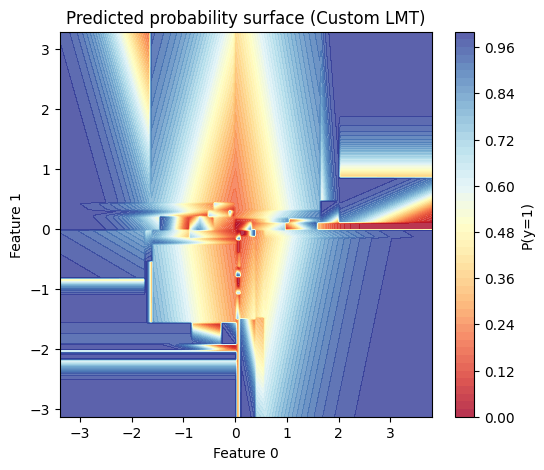

In [32]:
plot_probability_surface_custom_tree(tree, node_models, X_train, feature_pair=(0,1), show_scatter=False)
plt.show()

## LMT with regression pruning

In [33]:
from sklearn.metrics import roc_auc_score
from collections import deque
from copy import deepcopy
import numpy as np

def get_sample_to_node_mask(root_node, X):
    """
    Given a tree built with DecisionNode and LeafNode objects,
    return a dictionary that maps each node_id to a boolean mask over the samples in X.
    """
    n_samples = X.shape[0]
    node_to_samples = {}

    for i in range(n_samples):
        x_i = X[i]
        node = root_node
        path = []

        while not node.is_leaf:
            path.append(node.node_id)
            f = node.feature
            tau = node.tau  # if this is a spline function, call tau(x)

            # If tau is a callable (e.g., spline), evaluate it
            if callable(tau):
                go_left = x_i[f] <= tau(x_i[f])
            else:
                go_left = x_i[f] <= tau

            node = node.left if go_left else node.right

        # Add the final leaf as well
        path.append(node.node_id)

        # Mark sample i as belonging to all nodes along its path
        for node_id in path:
            if node_id not in node_to_samples:
                node_to_samples[node_id] = np.zeros(n_samples, dtype=bool)
            node_to_samples[node_id][i] = True

    return node_to_samples


def regression_pruning_spline_bfs(
    X,
    y,
    root_node,
    node_models,
    threshold,
    multiclass=False,
    average='macro',
    verbose=False
):
    """
    Prunes a spline-based LMT tree using AUC performance at each node.

    Parameters
    ----------
    X : ndarray of shape (n_samples, n_features)
    y : ndarray of shape (n_samples,)
    root_node : Node
        Root of the tree structure (custom tree).
    node_models : dict
        node_id → {'learners': ..., 'J': ...}
    threshold : float
        Minimum AUC to keep a node.
    multiclass : bool
    average : str
        Average type for multiclass AUC.
    verbose : bool

    Returns
    -------
    pruned_root : Node
        Root of the pruned tree.
    pruned_node_models : dict
        node_id → model info, excluding pruned nodes.
    """

    pruned_root = deepcopy(root_node)
    pruned_node_models = deepcopy(node_models)
    sample_masks = get_sample_to_node_mask(pruned_root, X)

    # BFS traversal with parent tracking
    queue = deque([(pruned_root, None, None)])  # (node, parent, is_left)

    while queue:
        node, parent, is_left = queue.popleft()

        if node is None or node.is_leaf:
            continue

        node_id = node.node_id
        mask = sample_masks.get(node_id, np.zeros(len(y), dtype=bool))
        X_node = X[mask]
        y_node = y[mask]

        # AUC calculation
        if len(np.unique(y_node)) < 2:
            perf = 1.0
        else:
            model_info = pruned_node_models[node_id]
            learners = model_info['learners']
            J = model_info['J']

            p = logitboost.logitboost_predict_proba(X_node, learners, J)
            perf = roc_auc_score(y_node, p if multiclass else p[:, 1], average=average if multiclass else 'macro')

        if verbose:
            print(f"[Node {node_id}] AUC = {perf:.4f}")

        if perf > threshold:
            if verbose:
                print(f"→ Pruning node {node_id} (AUC={perf:.4f})")

            # Convert to real LeafNode
            new_leaf = LeafNode(y_node, node_id=node.node_id)

            # Replace in parent
            if parent is None:
                pruned_root = new_leaf
            else:
                if is_left:
                    parent.left = new_leaf
                else:
                    parent.right = new_leaf

            # Clean up children models
            if node.left:
                pruned_node_models.pop(node.left.node_id, None)
            if node.right:
                pruned_node_models.pop(node.right.node_id, None)

            # Remove model for this node if needed
            # (optional: keep it for leaf prediction)
        else:
            queue.append((node.left, node, True))
            queue.append((node.right, node, False))

    return pruned_root, pruned_node_models



In [34]:
pruned_tree, pruned_node_models = regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.8, multiclass=False, average='macro', verbose=True
)

[Node 104] AUC = 0.5045
[Node 54] AUC = 0.7151
[Node 103] AUC = 0.7283
[Node 26] AUC = 0.7403
[Node 53] AUC = 0.7755
[Node 79] AUC = 0.7596
[Node 102] AUC = 0.7401
[Node 10] AUC = 0.6382
[Node 25] AUC = 0.6856
[Node 39] AUC = 0.8094
→ Pruning node 39 (AUC=0.8094)
[Node 52] AUC = 0.7571
[Node 65] AUC = 0.4065
[Node 78] AUC = 0.7565
[Node 86] AUC = 0.2890
[Node 101] AUC = 0.7239
[Node 4] AUC = 0.7833
[Node 9] AUC = 0.8163
→ Pruning node 9 (AUC=0.8163)
[Node 17] AUC = 0.7749
[Node 24] AUC = 0.7076
[Node 44] AUC = 0.7470
[Node 51] AUC = 0.7805
[Node 59] AUC = 0.7654
[Node 64] AUC = 0.6312
[Node 70] AUC = 0.7481
[Node 77] AUC = 0.7726
[Node 85] AUC = 0.7697
[Node 93] AUC = 0.7203
[Node 100] AUC = 0.5460
[Node 3] AUC = 0.7500
[Node 13] AUC = 0.8512
→ Pruning node 13 (AUC=0.8512)
[Node 16] AUC = 0.7368
[Node 20] AUC = 0.6876
[Node 23] AUC = 0.7057
[Node 43] AUC = 0.7786
[Node 47] AUC = 0.7955
[Node 50] AUC = 0.7719
[Node 57] AUC = 0.7456
[Node 63] AUC = 0.6776
[Node 68] AUC = 0.7278
[Node 73]

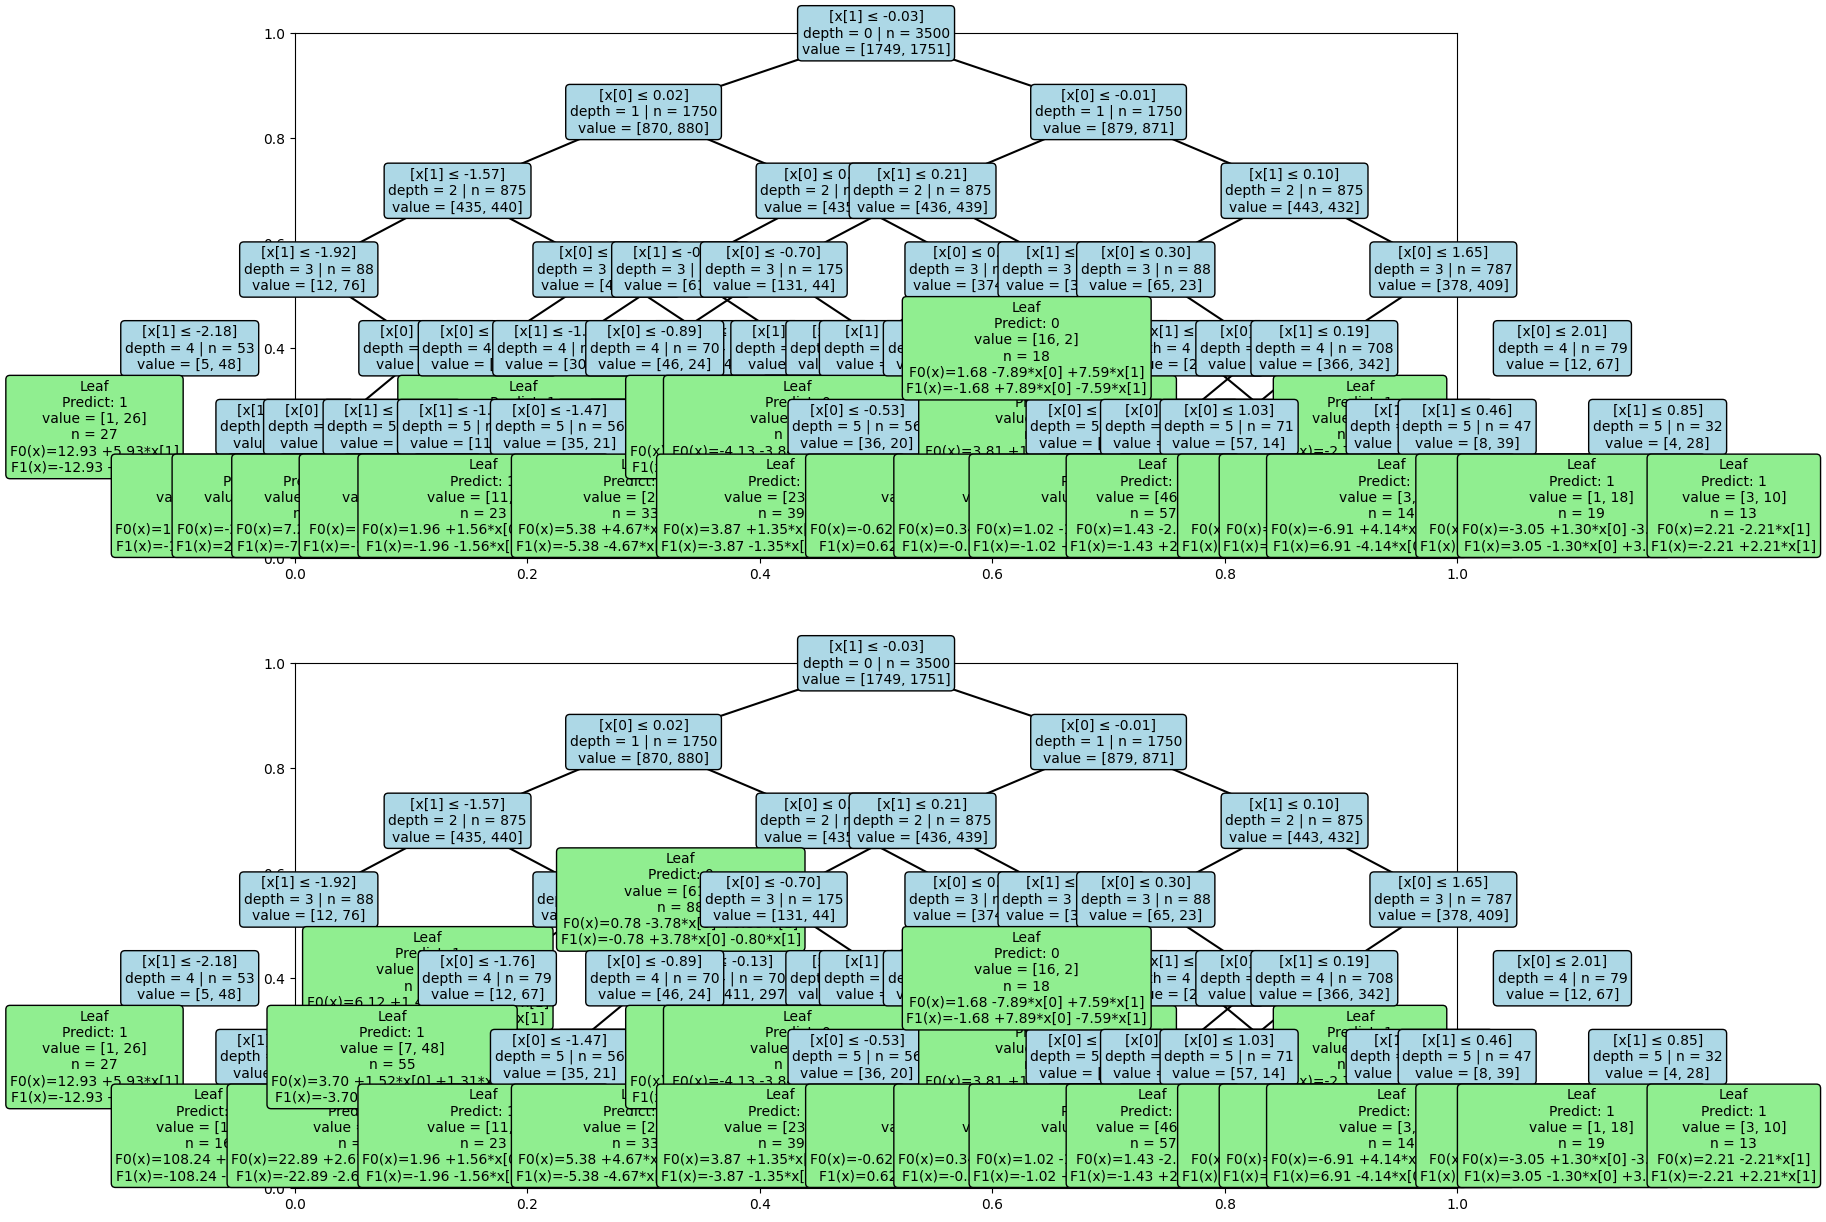

In [35]:
# Subplot for comparing original and pruned trees
# Subplt for the decision surface and the probability surface
fig, ax = plt.subplots(2, 1, figsize=(15, 15))
# Same feature
plot_custom_tree_with_models(
    tree, node_models, X_train, ax=ax[0], title="Original Custom LMT with LogitBoost Models")
plot_custom_tree_with_models(
    pruned_tree, pruned_node_models, X_train, ax=ax[1], title="Pruned Custom LMT with LogitBoost Models")
plt.show()

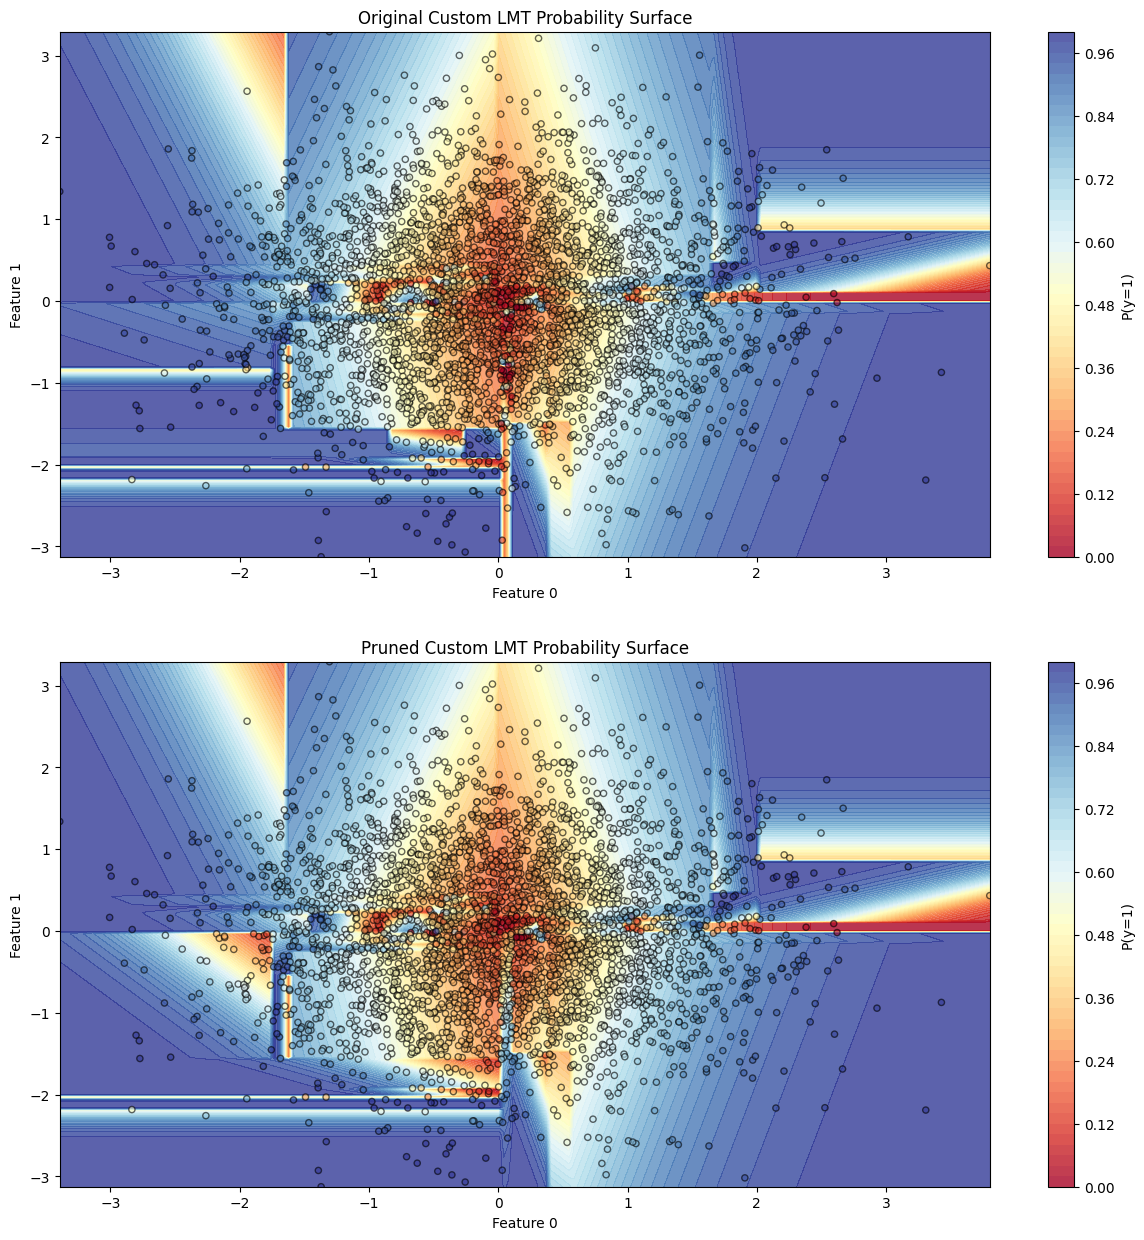

In [36]:
# Subplot for comparing original and pruned trees
# Subplt for the decision surface and the probability surface
fig, ax = plt.subplots(2, 1, figsize=(15, 15))
plot_probability_surface_custom_tree(
    tree, node_models, X_train, feature_pair=(0, 1), ax=ax[0], title="Original Custom LMT Probability Surface")
plot_probability_surface_custom_tree(
    pruned_tree, pruned_node_models, X_train, feature_pair=(0, 1), ax=ax[1], title="Pruned Custom LMT Probability Surface")
plt.show()


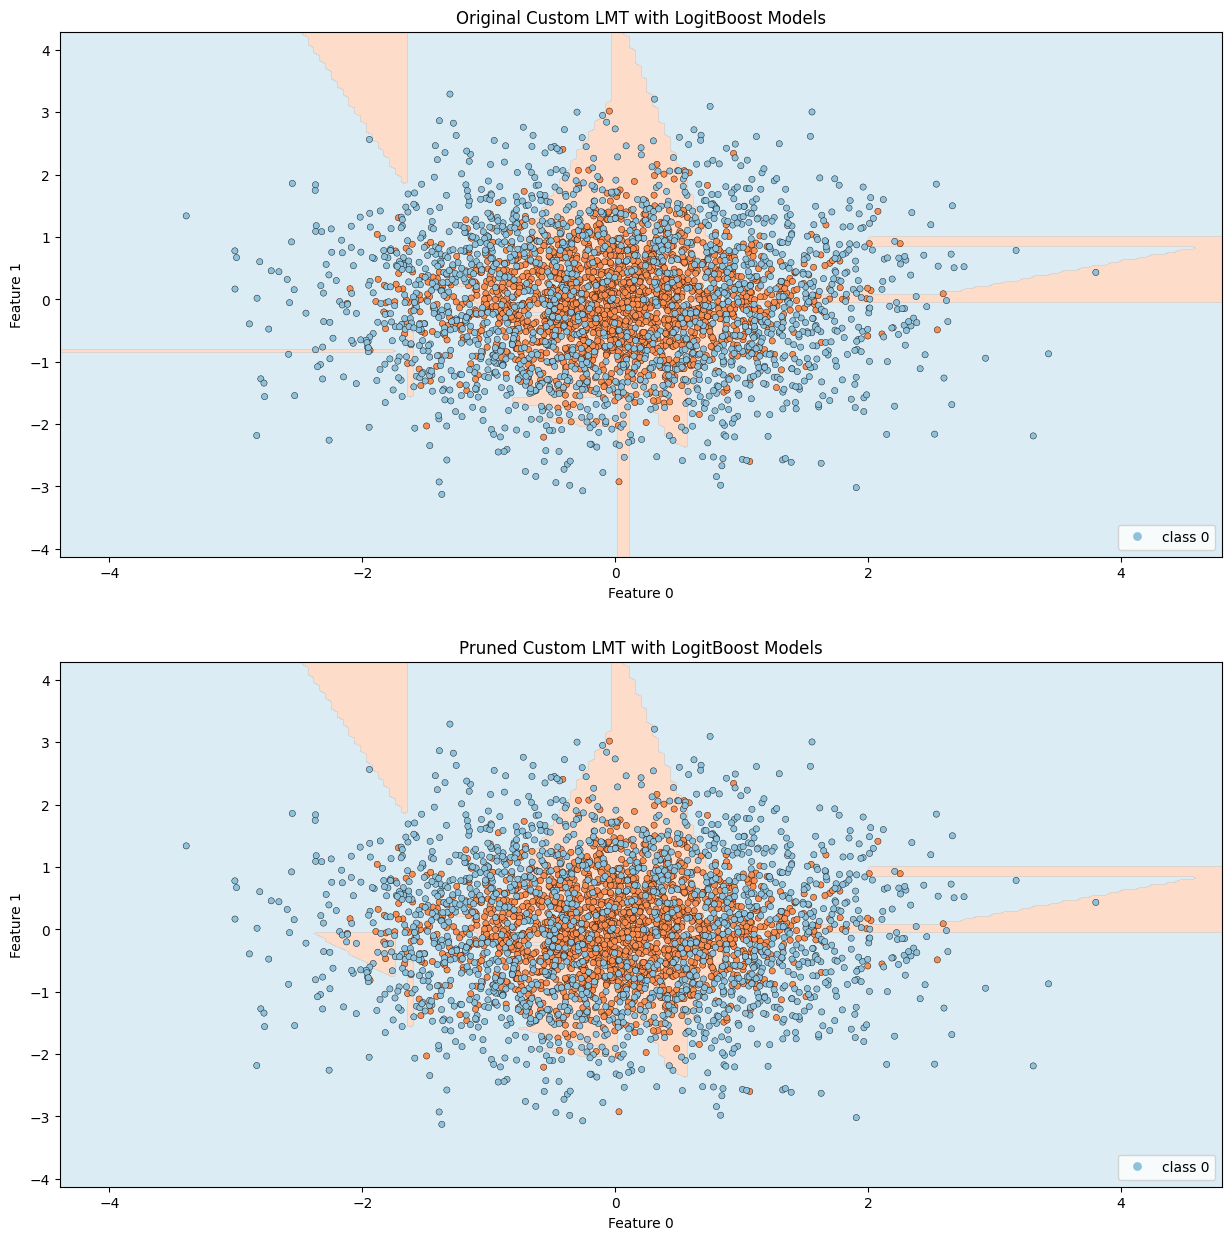

In [37]:
# Subplot for comparing original and pruned trees
# Subplt for the decision surface and the probability surface
fig, ax = plt.subplots(2, 1, figsize=(15, 15))
# Same feature
plot_decision_regions_custom_tree(
    X_train, y_train, tree, node_models, ax=ax[0], title="Original Custom LMT with LogitBoost Models",)
plot_decision_regions_custom_tree(
    X_train, y_train, pruned_tree, pruned_node_models, ax=ax[1], title="Pruned Custom LMT with LogitBoost Models")
plt.show()

## Calibration

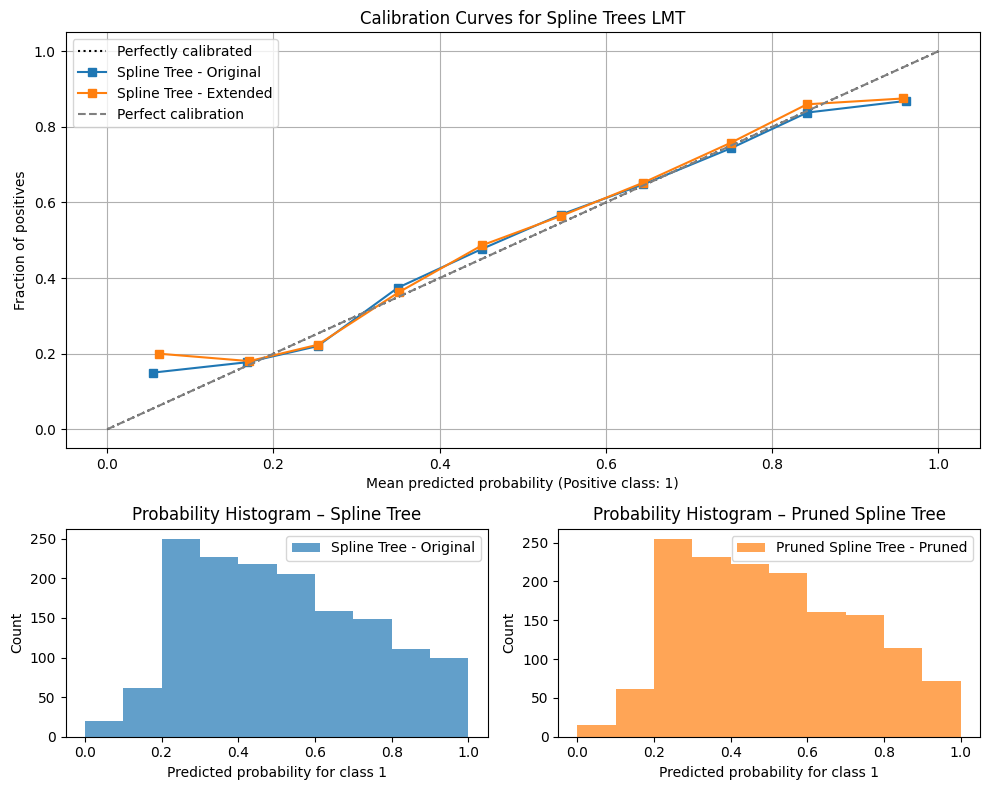

In [46]:
fig = plt.figure(figsize=(10, 8))
gs = GridSpec(2, 2, figure=fig, height_ratios=[2, 1])

ax_curve = fig.add_subplot(gs[0, :])
ax_hist1 = fig.add_subplot(gs[1, 0])
ax_hist2 = fig.add_subplot(gs[1, 1])

colors = plt.get_cmap("tab10")

clfs_original = [(tree, node_models)]
clfs_extended = [(pruned_tree, pruned_node_models)]
model_labels = ["Spline Tree", "Pruned Spline Tree"]

# --- Calibration curve ---
for idx, (clf_o, clf_e) in enumerate(zip(clfs_original, clfs_extended)):
    proba_o = predict_proba_lmt_custom(X_test, clf_o[0], clf_o[1])[:, 1]
    proba_e = predict_proba_lmt_custom(X_test, clf_e[0], clf_e[1])[:, 1]

    CalibrationDisplay.from_predictions(
        y_test, proba_o, n_bins=n_bins,
        name=f"{model_labels[idx]} - Original",
        ax=ax_curve, color=colors(2 * idx)
    )
    CalibrationDisplay.from_predictions(
        y_test, proba_e, n_bins=n_bins,
        name=f"{model_labels[idx]} - Extended",
        ax=ax_curve, color=colors(2 * idx + 1)
    )

ax_curve.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax_curve.set_title("Calibration Curves for Spline Trees LMT")
ax_curve.set_xlabel("Mean predicted probability (Positive class: 1)")
ax_curve.set_ylabel("Fraction of positives")
ax_curve.grid(True)
ax_curve.legend(loc='best')

# --- First histogram (spline tree lmt) ---
ax_hist1.hist(proba_o, bins=n_bins, range=(0, 1), alpha=0.7, color=colors(0), label=f"{model_labels[0]} - Original")
ax_hist1.set_title(f"Probability Histogram – {model_labels[0]}")
ax_hist1.set_xlabel("Predicted probability for class 1")
ax_hist1.set_ylabel("Count")
ax_hist1.legend()

# --- Second histogram (pruned spline tree lmt) ---
ax_hist2.hist(proba_e, bins=n_bins, range=(0, 1), alpha=0.7, color=colors(1), label=f"{model_labels[1]} - Pruned")
ax_hist2.set_title(f"Probability Histogram – {model_labels[1]}")
ax_hist2.set_xlabel("Predicted probability for class 1")
ax_hist2.set_ylabel("Count")
ax_hist2.legend()

fig.tight_layout()
plt.show()

C:\Users\allis\AppData\Local\Temp\ipykernel_12588\2620002011.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


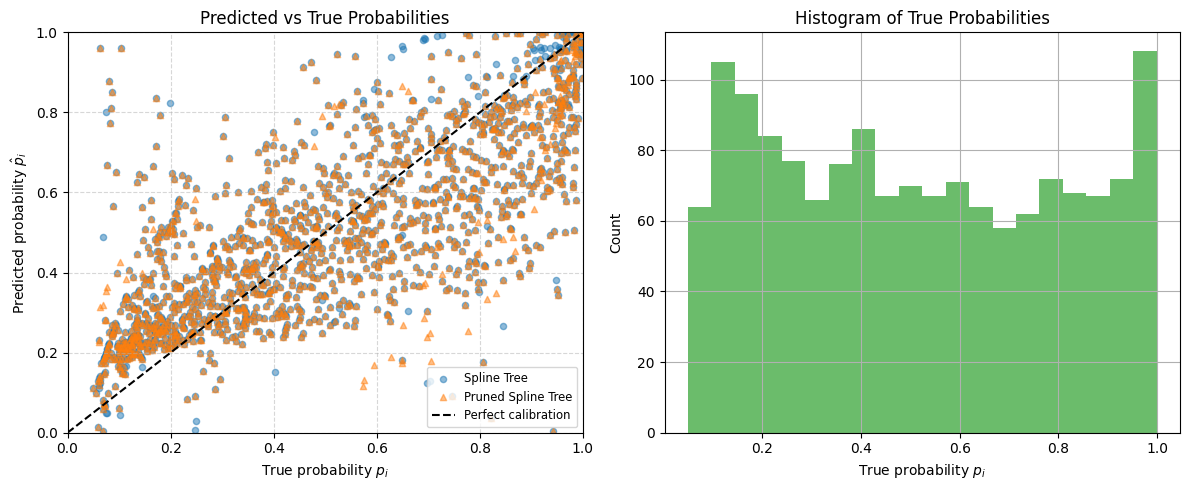

In [47]:
p_true = expit(alpha * (np.abs(X_test[:, 0]) + np.abs(X_test[:, 1]) - r0))
models = {
    'Spline Tree': (tree, node_models),
    'Pruned Spline Tree': (pruned_tree, pruned_node_models)
}

plot_pred_vs_true(models, p_true, X_test, model_type='spline_lmt', orig_cols=2, figsize=(12, 5))
plt.show()

# Random Search for best parameters

In [ ]:
def pipeline_spline_tree_lmt(
    X_train, y_train, X_test, y_test,
    features=[0, 1],
    max_depth=6,
    min_samples_leaf=10,
    purity_threshold=0.95,
    lb_n_estimators=200,
    lb_eps=1e-5,
    lb_cv_splits=5,
    lb_random_state=0,
    pruning_threshold=0.8,
    multiclass=False,
    average='macro',
    verbose=False
):
    """
    Full pipeline to fit a custom Logistic Model Tree with LogitBoost and prune it.
    
    Parameters
    ----------
    X_train, y_train : training data
    X_test, y_test : test data
    features : list of feature indices to use
    max_depth, min_samples_leaf, purity_threshold : tree parameters
    lb_* : LogitBoost parameters
    pruning_threshold : AUC threshold for pruning
    multiclass : whether the problem is multiclass
    average : averaging method for AUC
    verbose : whether to print progress
    """
    # Step 1: Fit the custom Logistic Model Tree
    tree, node_models = fit_logistic_model_tree_custom(
        X_train, y_train,
        features=features,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        purity_threshold=purity_threshold,
        verbose=verbose,
        lb_n_estimators=lb_n_estimators,
        lb_eps=lb_eps,
        lb_cv_splits=lb_cv_splits,
        lb_random_state=lb_random_state
    )

    # Step 2: Prune the tree based on AUC performance
    pruned_tree, pruned_node_models = regression_pruning_spline_bfs(
        X_train, y_train, tree, node_models,
        threshold=pruning_threshold,
        multiclass=multiclass,
        average=average,
        verbose=verbose
    )

    # Step 3: Predict and evaluate on test set
    y_pred = predict_lmt_custom(X_test, pruned_tree, pruned_node_models)
    accuracy = np.mean(y_pred == y_test)

    return pruned_tree, pruned_node_models, accuracy


from sklearn.model_selection import ParameterGrid
import time
import random

param_grid = {
    'max_depth': [6, 8, 10, 12, 15],
    'min_samples_leaf': [10, 20, 30],
    'purity_threshold': [0.75, 0.8, 0.85, 0.9, 0.95],
    'pruning_threshold': [0.7, 0.75, 0.8, 0.85, 0.9],
}

# Generate full grid and sample 30 unique combinations
full_grid = list(ParameterGrid(param_grid))
sampled_params = random.sample(full_grid, k=30)

best_acc = -np.inf
best_tree = None
best_params = None

# Random Search over the parameter grid
for i, params in enumerate(sampled_params, 1):
    print(f"Training iteration {i}/{len(sampled_params)} with parameters: {params}")
    start_time = time.time()
    tree, node_models, acc = pipeline_spline_tree_lmt(
        X_train, y_train, X_test, y_test,
        features=[0, 1],
        max_depth=params['max_depth'],
        min_samples_leaf=params['min_samples_leaf'],
        purity_threshold=params['purity_threshold'],
        lb_n_estimators=200,
        lb_eps=1e-5,
        lb_cv_splits=5,
        lb_random_state=0,
        pruning_threshold=params['pruning_threshold'],
        multiclass=False,
        average='macro',
        verbose=False
    )
    elapsed_time = time.time() - start_time
    print(f"Training time: {elapsed_time:.2f} seconds")
    print(f"Accuracy: {acc:.4f}\n")
    
    if acc > best_acc:
        best_acc = acc
        best_tree = tree
        best_params = params

print(f"Best accuracy: {best_acc:.4f} with parameters: {best_params}")

Training iteration 1/30 with parameters: {'max_depth': 6, 'min_samples_leaf': 10, 'pruning_threshold': 0.85, 'purity_threshold': 0.85}
Training time: 11.14 seconds
Accuracy: 0.6813

Training iteration 2/30 with parameters: {'max_depth': 10, 'min_samples_leaf': 30, 'pruning_threshold': 0.9, 'purity_threshold': 0.85}
Training time: 12.80 seconds
Accuracy: 0.6820

Training iteration 3/30 with parameters: {'max_depth': 12, 'min_samples_leaf': 30, 'pruning_threshold': 0.75, 'purity_threshold': 0.85}
Training time: 13.78 seconds
Accuracy: 0.6740

Training iteration 4/30 with parameters: {'max_depth': 8, 'min_samples_leaf': 30, 'pruning_threshold': 0.75, 'purity_threshold': 0.95}
Training time: 12.40 seconds
Accuracy: 0.6840

Training iteration 5/30 with parameters: {'max_depth': 15, 'min_samples_leaf': 20, 'pruning_threshold': 0.9, 'purity_threshold': 0.75}
Training time: 14.78 seconds
Accuracy: 0.6793

Training iteration 6/30 with parameters: {'max_depth': 10, 'min_samples_leaf': 20, 'pruni

In [51]:
accuracies = [
    0.6813, 0.6820, 0.6740, 0.6840, 0.6793, 0.6960, 0.6953, 0.6580, 0.6687, 0.6953,
    0.6893, 0.6840, 0.6687, 0.6880, 0.6687, 0.6687, 0.6887, 0.6687, 0.6687, 0.6860,
    0.6840, 0.6913, 0.6780, 0.6953, 0.6907, 0.6673, 0.6640, 0.6913, 0.6880, 0.6913
]

np_accuracies = np.array(accuracies)

stats = {
    "mean": np.round(np.mean(np_accuracies), 4),
    "std": np.round(np.std(np_accuracies), 4),
    "min": np.round(np.min(np_accuracies), 4),
    "max": np.round(np.max(np_accuracies), 4),
    "median": np.round(np.median(np_accuracies), 4),
    "25th_percentile": np.round(np.percentile(np_accuracies, 25), 4),
    "75th_percentile": np.round(np.percentile(np_accuracies, 75), 4)
}

stats


{'mean': 0.6812,
 'std': 0.0108,
 'min': 0.658,
 'max': 0.696,
 'median': 0.684,
 '25th_percentile': 0.6687,
 '75th_percentile': 0.6904}

In [ ]:
# Training iteration 6/30 with parameters: {'max_depth': 10, 'min_samples_leaf': 20, 'pruning_threshold': 0.9, 'purity_threshold': 0.85}
# Training time: 14.15 seconds
# Accuracy: 0.6960



## Spline Tree

In [52]:
spline_tree = grow_spline_tree(X_train, y_train, [0,1], max_depth=10, min_samples_leaf=20, purity_threshold=0.85, verbose=True)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

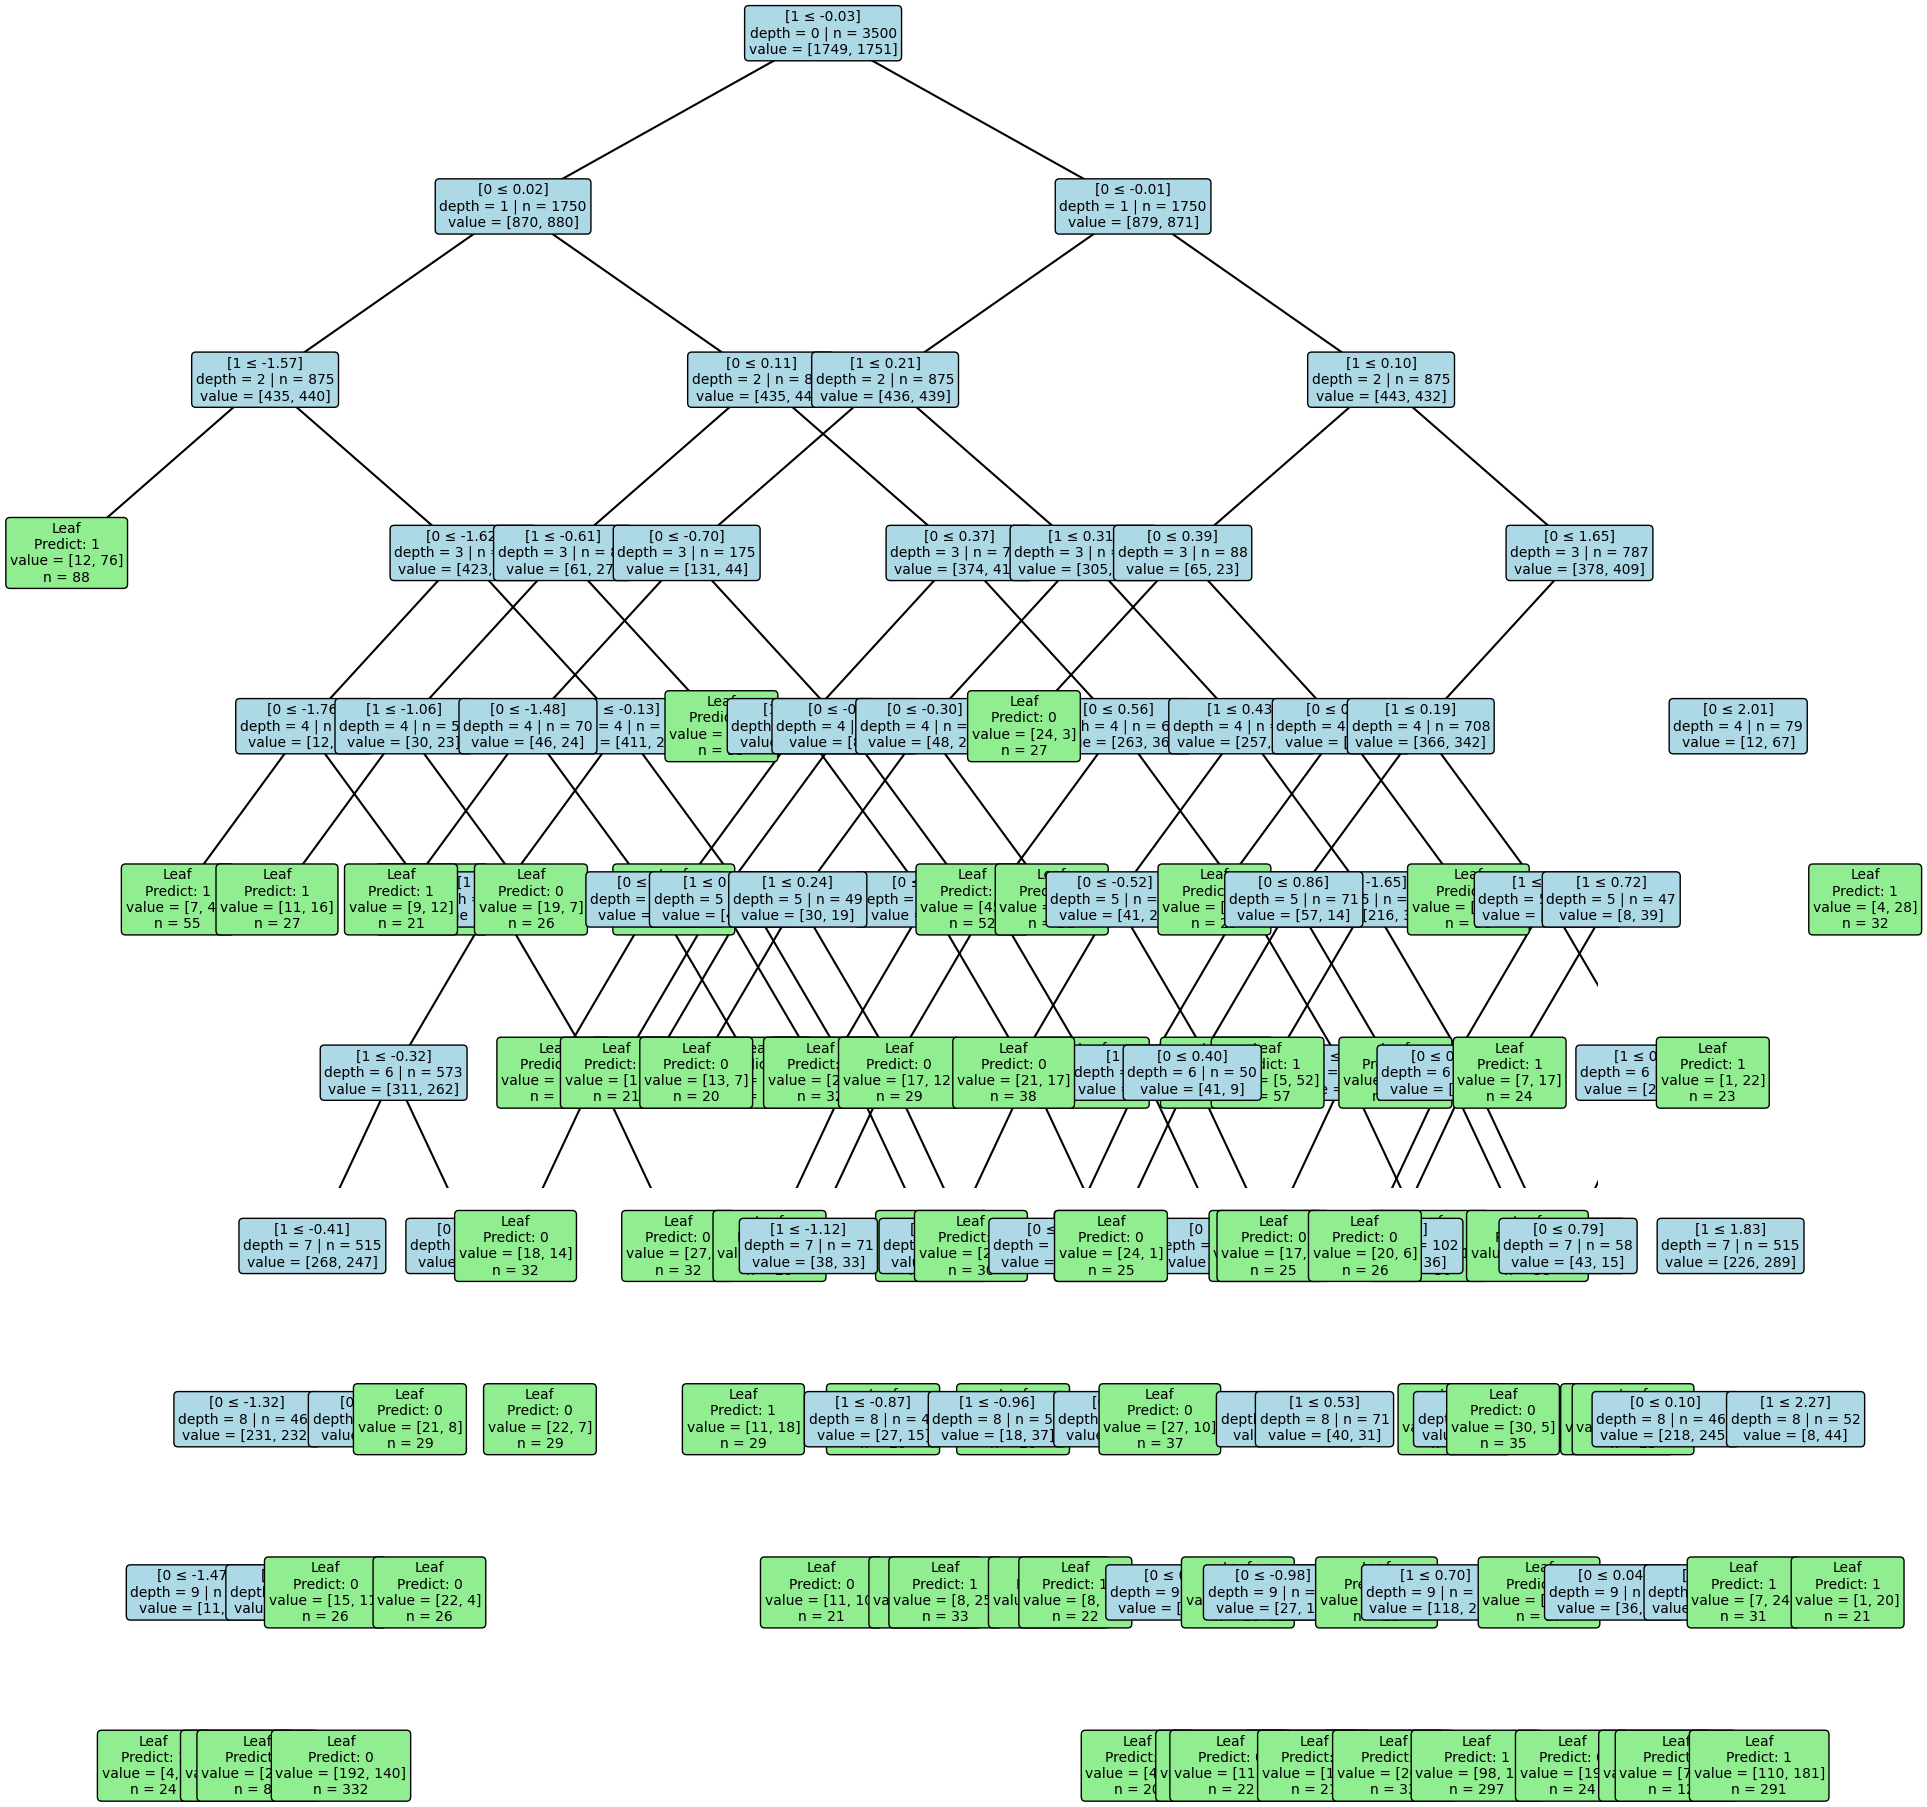

In [ ]:
plot_custom_tree(spline_tree)

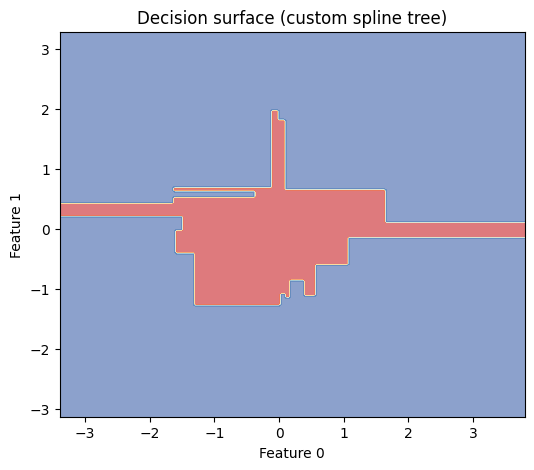

In [60]:
plot_decision_surface_from_custom_tree(spline_tree, X_train, (0, 1))
plt.show()

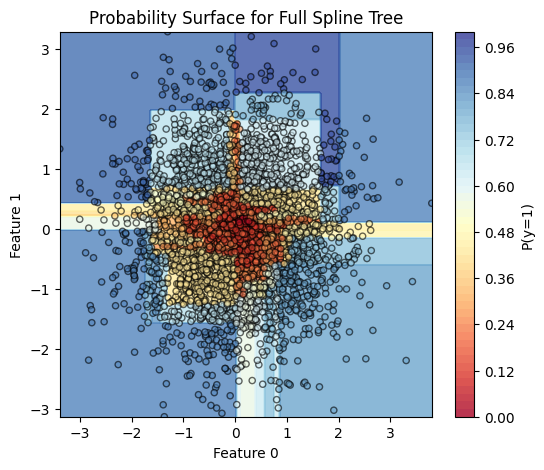

In [61]:
plot_probability_surface_tree(
    spline_tree, X_train, (0, 1), prob_class=1, title='Probability Surface for Full Spline Tree',)
plt.show()

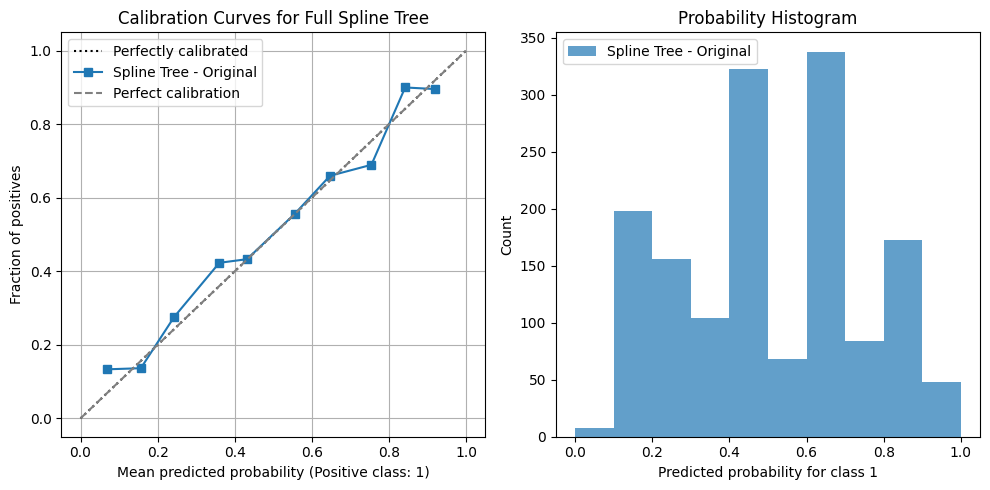

In [62]:
fig = plt.figure(figsize=(10, 5))
gs = GridSpec(1, 2, figure=fig)

ax_curve = fig.add_subplot(gs[0])
ax_hist1 = fig.add_subplot(gs[1])

colors = plt.get_cmap("tab10")

# --- Calibration curve ---
n_bins = 10
proba_o = predict_proba(X_test, spline_tree)[:, 1]
    

CalibrationDisplay.from_predictions(
    y_test, proba_o, n_bins=n_bins,
    name=f"Spline Tree - Original",
    ax=ax_curve, color=colors(2 * 0)
)
    

ax_curve.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax_curve.set_title("Calibration Curves for Full Spline Tree")
ax_curve.set_xlabel("Mean predicted probability (Positive class: 1)")
ax_curve.set_ylabel("Fraction of positives")
ax_curve.grid(True)
ax_curve.legend(loc='best')

# --- First histogram (model 0 original vs extended) ---
ax_hist1.hist(proba_o, bins=n_bins, range=(0, 1), alpha=0.7, color=colors(0), label=f"Spline Tree - Original")
ax_hist1.set_title(f"Probability Histogram")
ax_hist1.set_xlabel("Predicted probability for class 1")
ax_hist1.set_ylabel("Count")
ax_hist1.legend()


fig.tight_layout()
plt.show()

C:\Users\allis\AppData\Local\Temp\ipykernel_12588\2620002011.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


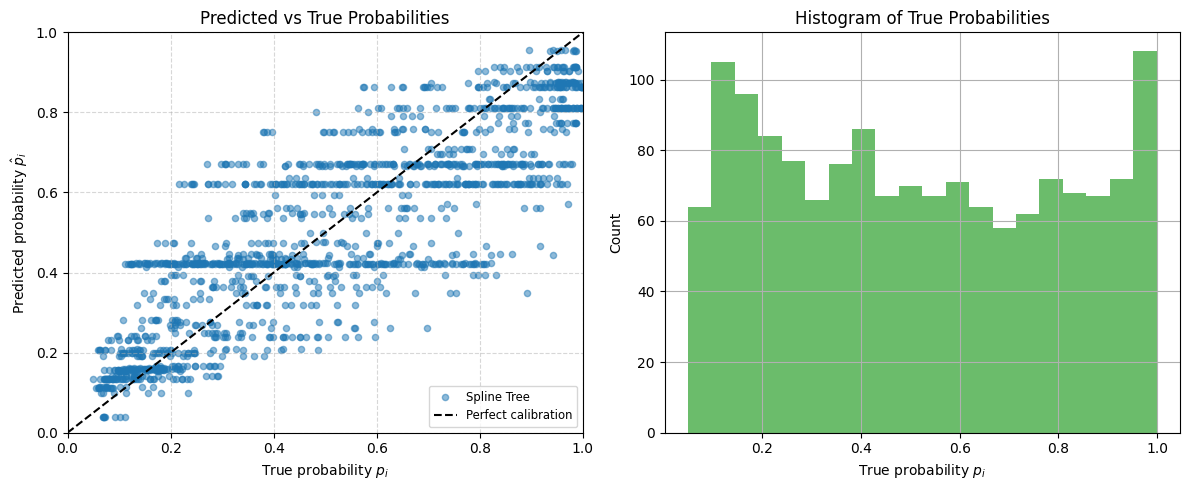

In [64]:
plot_pred_vs_true({'Spline Tree': spline_tree}, p_true, X_test, model_type='spline_tree', orig_cols=2, figsize=(12, 5))
plt.show()

In [67]:
# Accuracy of the full spline tree
# Training
y_pred_spline_tree = predict(X_train, spline_tree)
accuracy_spline_tree = np.mean(y_pred_spline_tree == y_train)
print(f"Accuracy of the full spline tree (Training): {accuracy_spline_tree:.4f}")   

y_pred_spline_tree = predict(X_test, spline_tree)
accuracy_spline_tree = np.mean(y_pred_spline_tree == y_test)
print(f"Accuracy of the full spline tree (Testing): {accuracy_spline_tree:.4f}")

Accuracy of the full spline tree (Training): 0.7080
Accuracy of the full spline tree (Testing): 0.7033


## LMT V2 with Regression Pruning

In [112]:
tree, node_models = fit_logistic_model_tree_custom(
    X_train, y_train,
    features=[0,1],
    max_depth=10,
    min_samples_leaf=20,
    purity_threshold=0.85,
    verbose=True
)
print("LMT fitted with custom parameters")

pruned_tree0, pruned_node_models0 = regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.70, multiclass=False, average='macro', verbose=False)

pruned_tree1, pruned_node_models1 = regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.73, multiclass=False, average='macro', verbose=False)

pruned_tree2, pruned_node_models2 = regression_pruning_spline_bfs(
    X_train, y_train, tree, node_models,
    threshold=0.75, multiclass=False, average='macro', verbose=False)

Feature 0, tau = -1.29, AUC_L = 0.632, AUC_R = 0.575, Weighted AUC = 0.580
Feature 0, tau = -0.82, AUC_L = 0.664, AUC_R = 0.628, Weighted AUC = 0.636
Feature 0, tau = -0.50, AUC_L = 0.658, AUC_R = 0.677, Weighted AUC = 0.671
Feature 0, tau = -0.25, AUC_L = 0.674, AUC_R = 0.715, Weighted AUC = 0.699
Feature 0, tau = -0.00, AUC_L = 0.707, AUC_R = 0.715, Weighted AUC = 0.711
Feature 0, tau = 0.24, AUC_L = 0.708, AUC_R = 0.697, Weighted AUC = 0.704
Feature 0, tau = 0.51, AUC_L = 0.679, AUC_R = 0.684, Weighted AUC = 0.681
Feature 0, tau = 0.84, AUC_L = 0.632, AUC_R = 0.665, Weighted AUC = 0.639
Feature 0, tau = 1.26, AUC_L = 0.574, AUC_R = 0.646, Weighted AUC = 0.581
Feature 1, tau = -1.27, AUC_L = 0.643, AUC_R = 0.577, Weighted AUC = 0.583
Feature 1, tau = -0.85, AUC_L = 0.666, AUC_R = 0.641, Weighted AUC = 0.646
Feature 1, tau = -0.53, AUC_L = 0.691, AUC_R = 0.683, Weighted AUC = 0.686
Feature 1, tau = -0.26, AUC_L = 0.704, AUC_R = 0.716, Weighted AUC = 0.712
Feature 1, tau = -0.03, AUC_L

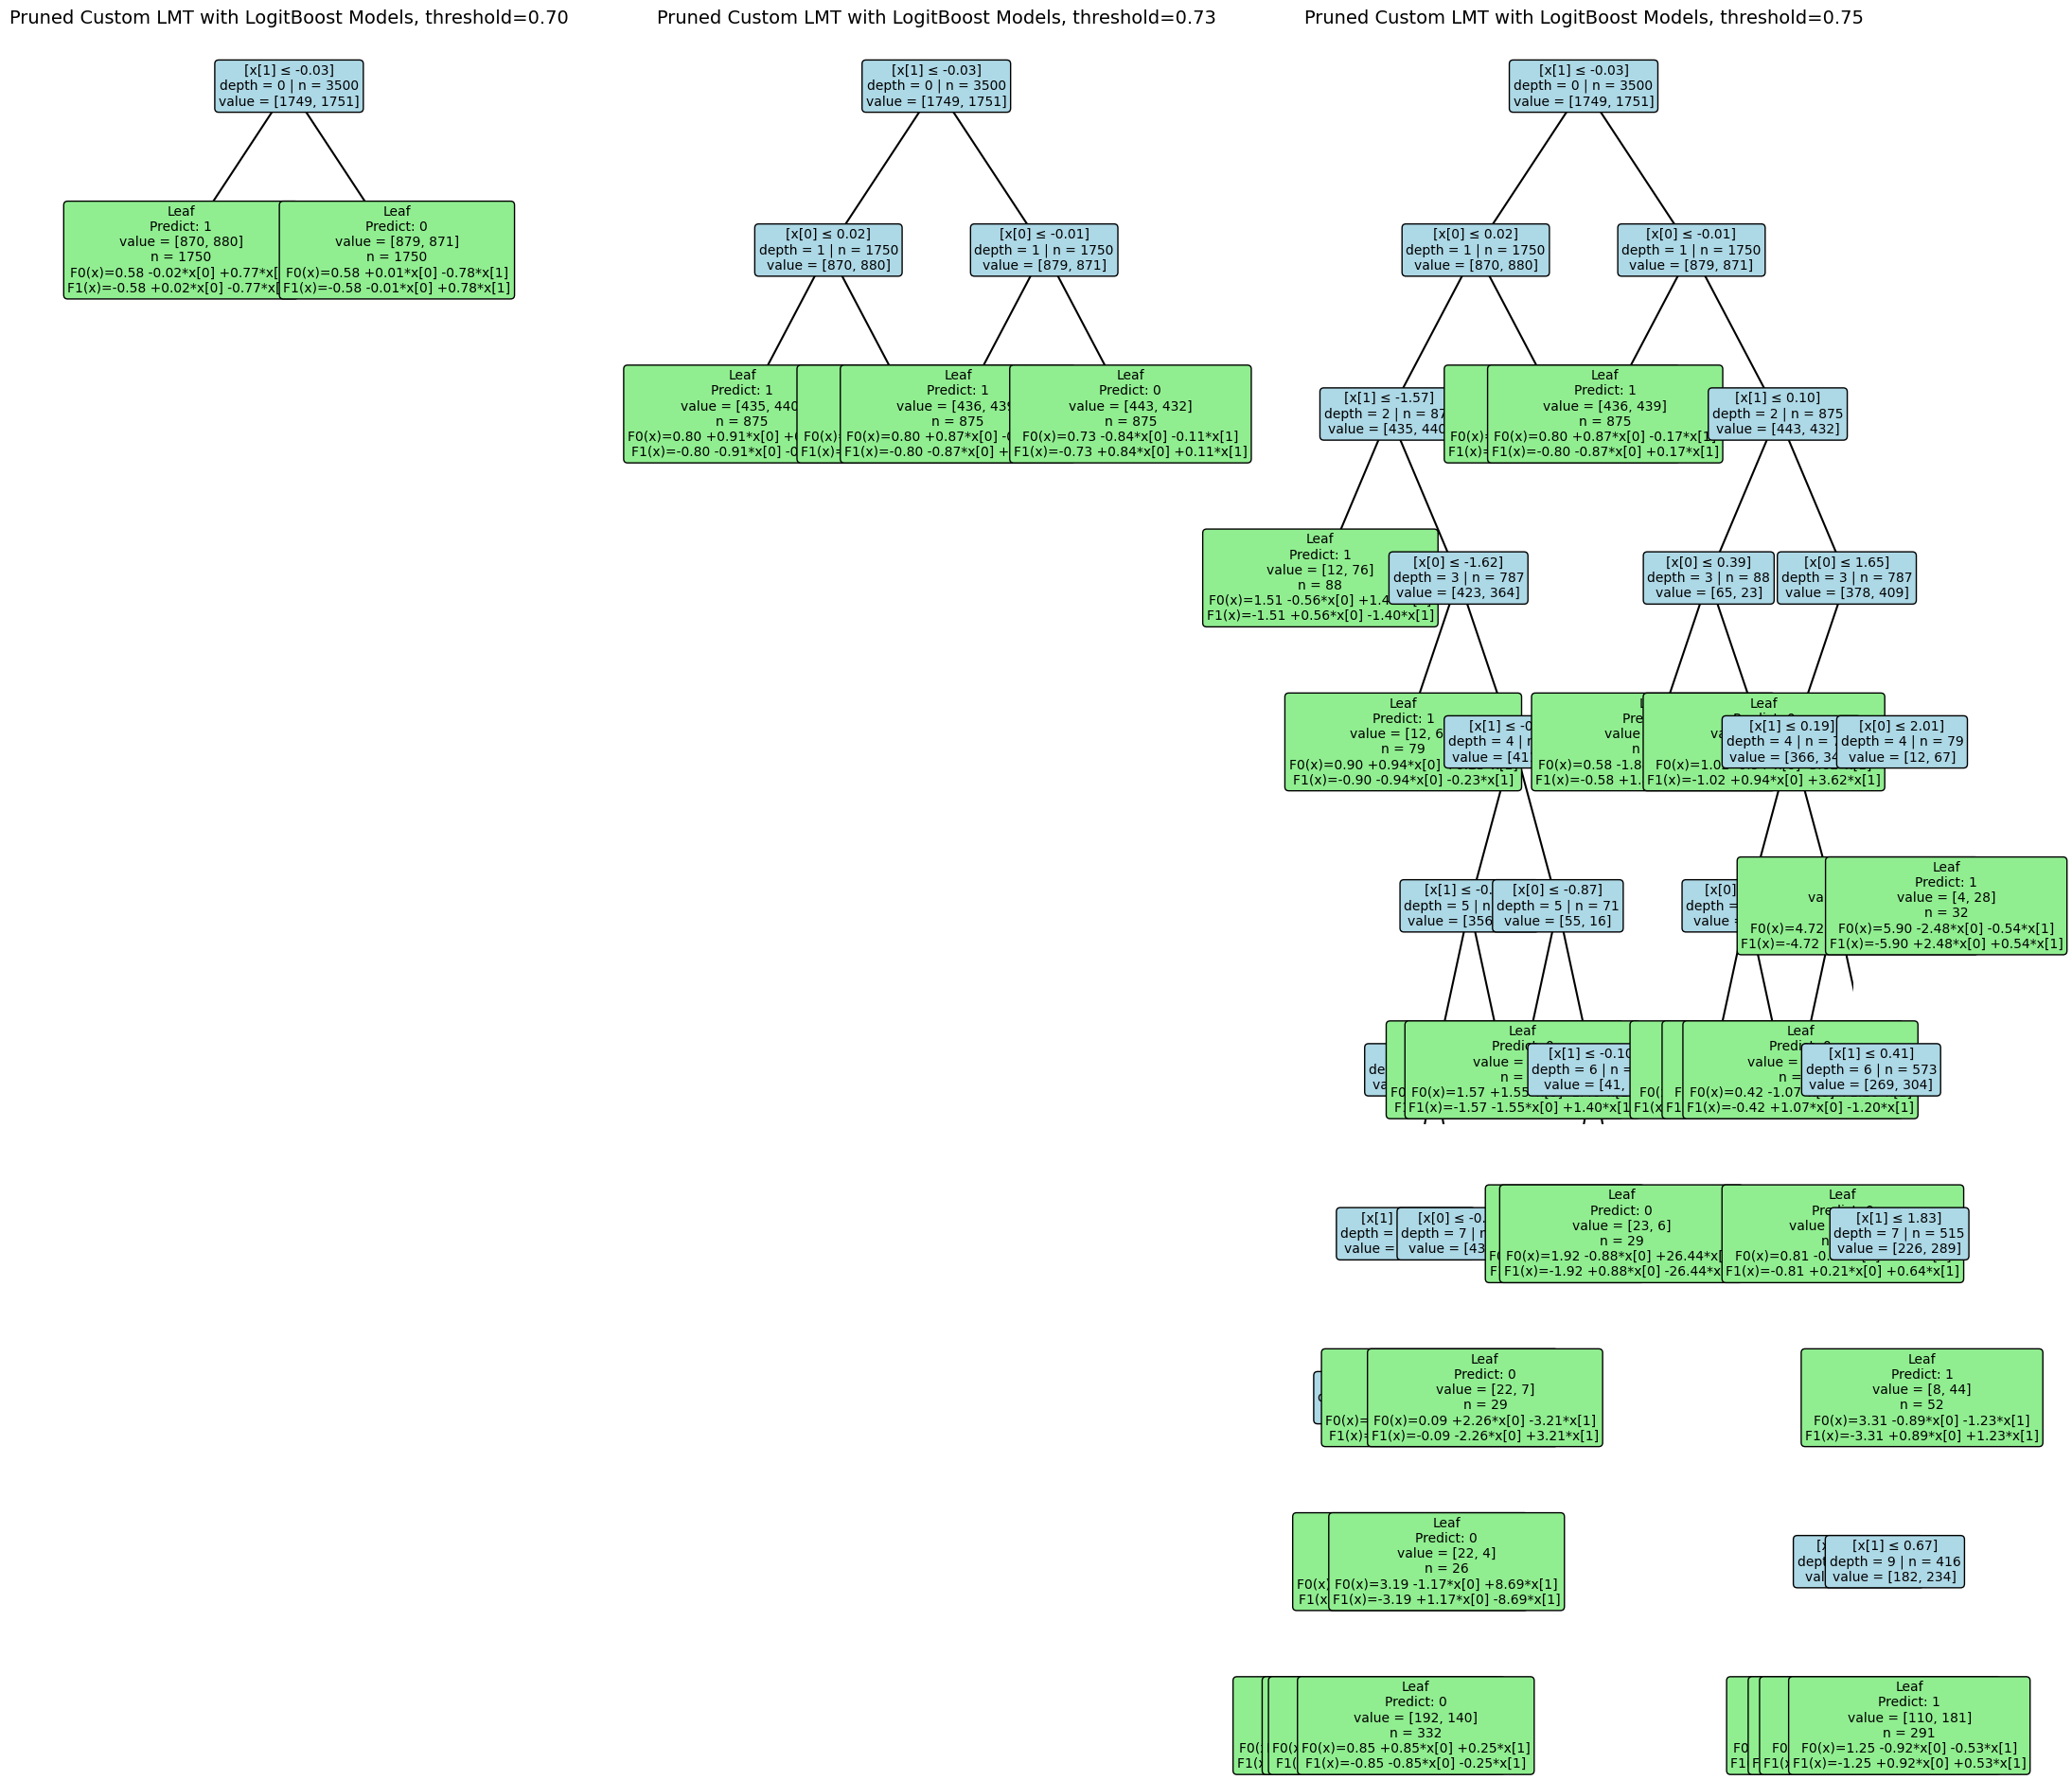

In [128]:
# Trees
fig, ax = plt.subplots(1, 3, figsize=(25, 15))
for axis in ax:
    axis.set_axis_off() 

plot_custom_tree_with_models(pruned_tree0, pruned_node_models0, X_train, ax=ax[0],title="Pruned Custom LMT with LogitBoost Models, threshold=0.70")
plot_custom_tree_with_models(pruned_tree1, pruned_node_models1, X_train, ax=ax[1],title="Pruned Custom LMT with LogitBoost Models, threshold=0.73")
plot_custom_tree_with_models(pruned_tree2, pruned_node_models2, X_train, ax=ax[2],title="Pruned Custom LMT with LogitBoost Models, threshold=0.75")

ax[0].set_title("Pruned Custom LMT with LogitBoost Models, threshold=0.70", fontsize=14)
ax[1].set_title("Pruned Custom LMT with LogitBoost Models, threshold=0.73", fontsize=14)
ax[2].set_title("Pruned Custom LMT with LogitBoost Models, threshold=0.75", fontsize=14)

plt.show()

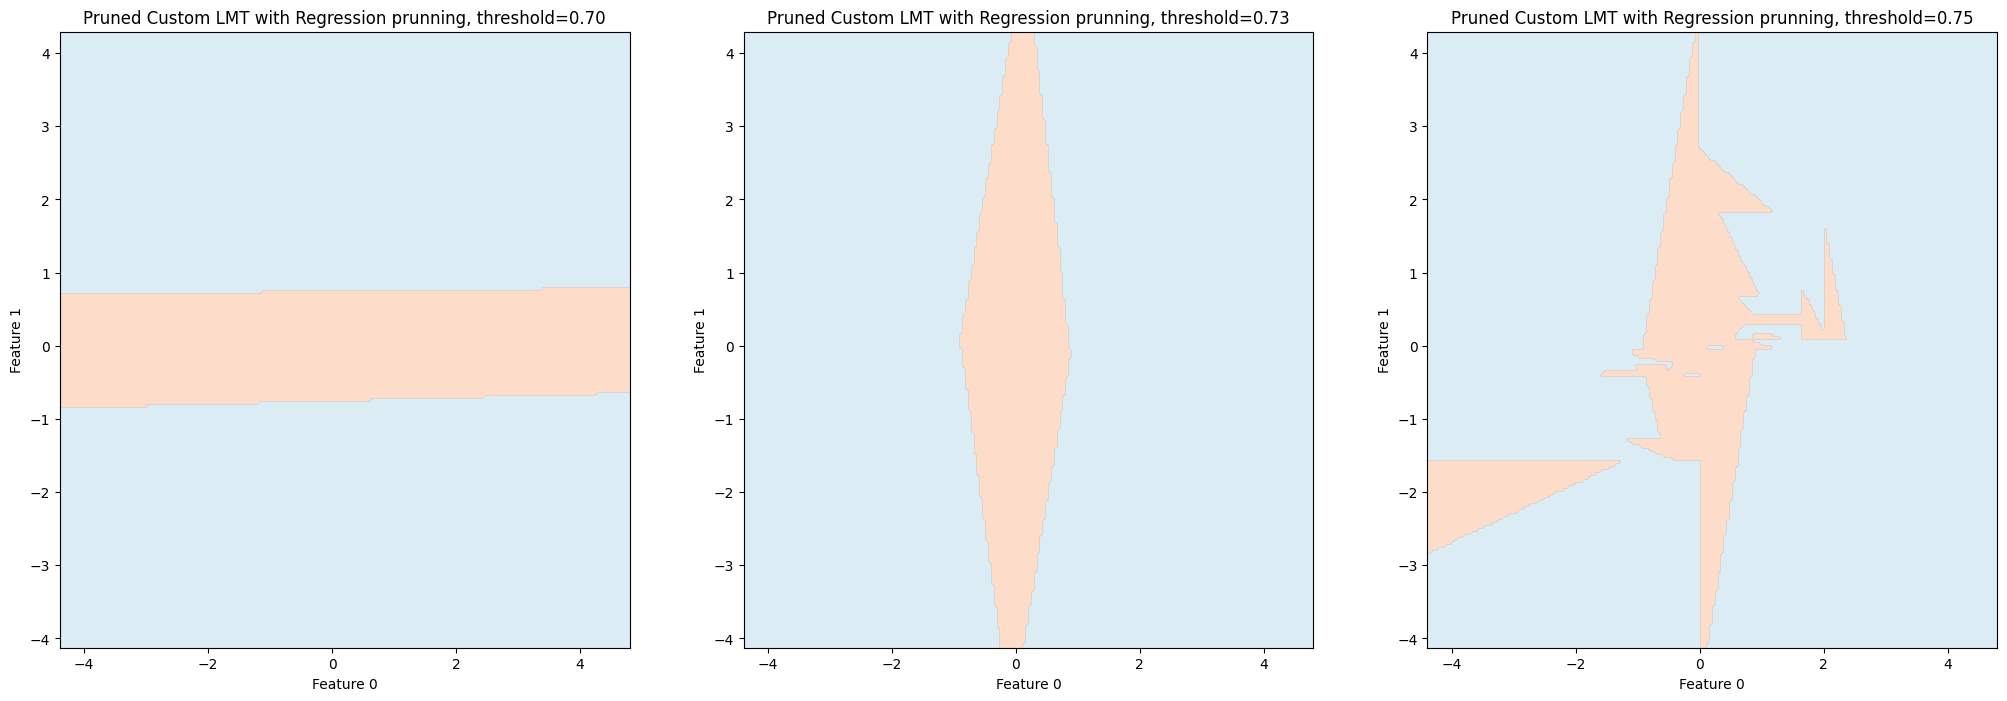

In [ ]:


# Decision regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

plot_decision_regions_custom_tree(
    X_train, y_train, pruned_tree0, pruned_node_models0, feature_pair=(0, 1), show_scatter=False, title="Pruned Custom LMT with Regression prunning, threshold=0.70", ax=ax[0]
    )
plot_decision_regions_custom_tree(
    X_train, y_train, pruned_tree1, pruned_node_models1, feature_pair=(0, 1), show_scatter=False, title="Pruned Custom LMT with Regression prunning, threshold=0.73", ax=ax[1]
    )
plot_decision_regions_custom_tree(
    X_train, y_train, pruned_tree2, pruned_node_models2, feature_pair=(0, 1), show_scatter=False, title="Pruned Custom LMT with Regression prunning, threshold=0.75", ax=ax[2]
    )

plt.show()

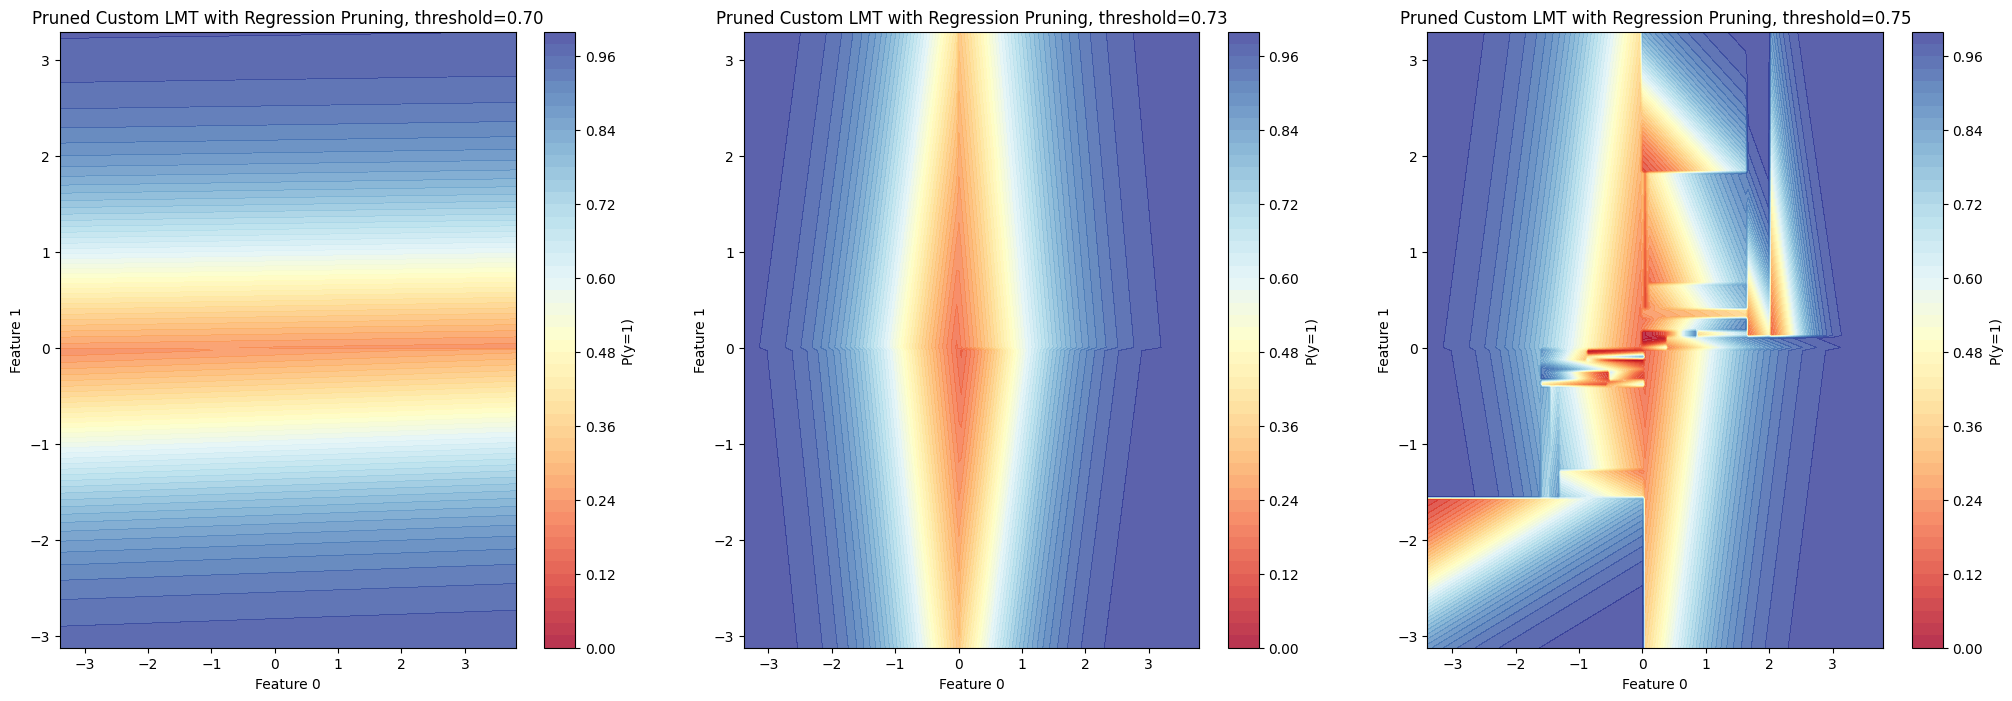

In [133]:
# Proability regions
fig, ax = plt.subplots(1, 3, figsize=(25, 8))

plot_probability_surface_custom_tree(
    pruned_tree0, pruned_node_models0, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title='Pruned Custom LMT with Regression Pruning, threshold=0.70', ax=ax[0]
    )
plot_probability_surface_custom_tree(
    pruned_tree1, pruned_node_models1, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title='Pruned Custom LMT with Regression Pruning, threshold=0.73', ax=ax[1]
    )
plot_probability_surface_custom_tree(
    pruned_tree2, pruned_node_models2, X_train, feature_pair=(0, 1), prob_class=1, show_scatter=False,
    title='Pruned Custom LMT with Regression Pruning, threshold=0.75', ax=ax[2]
    )

plt.show()

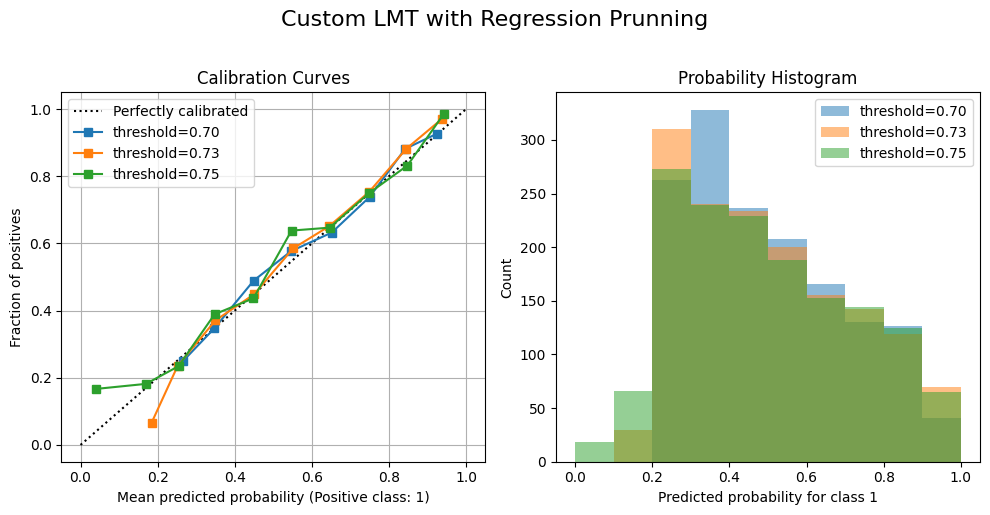

In [141]:
fig = plt.figure(figsize=(10, 5))
gs = GridSpec(1, 2, figure=fig)

ax_curve = fig.add_subplot(gs[0])
ax_hist1 = fig.add_subplot(gs[1])

colors = plt.get_cmap("tab10")

# --- Calibration curve ---
n_bins = 10
proba_0 = predict_proba_lmt_custom(X_test, pruned_tree0, pruned_node_models0)[:, 1]
proba_1 = predict_proba_lmt_custom(X_test, pruned_tree1, pruned_node_models1)[:, 1]
proba_2 = predict_proba_lmt_custom(X_test, pruned_tree2, pruned_node_models2)[:, 1]
    

CalibrationDisplay.from_predictions(
    y_test, proba_0, n_bins=n_bins,
    name=f"threshold=0.70",
    ax=ax_curve, color=colors(0)
)
CalibrationDisplay.from_predictions(
    y_test, proba_1, n_bins=n_bins,
    name=f"threshold=0.73",
    ax=ax_curve, color=colors(1)
)
CalibrationDisplay.from_predictions(
    y_test, proba_2, n_bins=n_bins,
    name=f"threshold=0.75",
    ax=ax_curve, color=colors(2)
)
    

#ax_curve.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
ax_curve.set_title("Calibration Curves")
ax_curve.set_xlabel("Mean predicted probability (Positive class: 1)")
ax_curve.set_ylabel("Fraction of positives")
ax_curve.grid(True)
ax_curve.legend(loc='best')

# --- First histogram (model 0 original vs extended) ---
ax_hist1.hist(proba_0, bins=n_bins, range=(0, 1), alpha=0.5, color=colors(0), label=f"threshold=0.70")
ax_hist1.hist(proba_1, bins=n_bins, range=(0, 1), alpha=0.5, color=colors(1), label=f"threshold=0.73")
ax_hist1.hist(proba_2, bins=n_bins, range=(0, 1), alpha=0.5, color=colors(2), label=f"threshold=0.75")

ax_hist1.set_title(f"Probability Histogram")
ax_hist1.set_xlabel("Predicted probability for class 1")
ax_hist1.set_ylabel("Count")
ax_hist1.legend()

# Suptitle for the entire figure
fig.suptitle("Custom LMT with Regression Prunning", fontsize=16, y=1.02)

fig.tight_layout()
plt.show()

C:\Users\allis\AppData\Local\Temp\ipykernel_12588\2620002011.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab10")


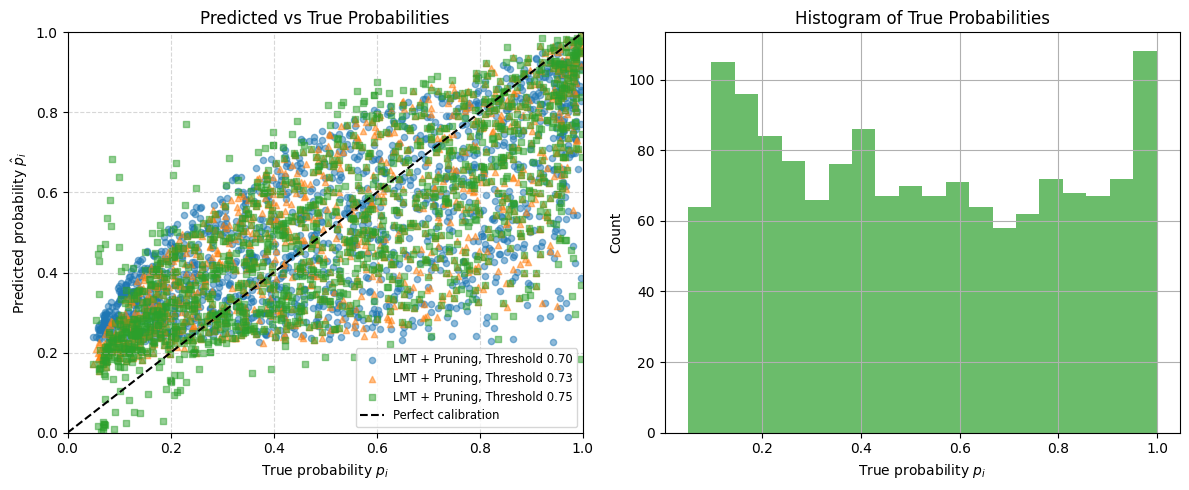

In [142]:
models_dict = {
        'LMT + Pruning, Threshold 0.70': (pruned_tree0, pruned_node_models0),
        'LMT + Pruning, Threshold 0.73': (pruned_tree1, pruned_node_models1),
        'LMT + Pruning, Threshold 0.75': (pruned_tree2, pruned_node_models2)
    }
plot_pred_vs_true(models_dict, p_true, X_test, model_type='spline_lmt', orig_cols=2, figsize=(12, 5))
plt.show()

In [110]:
# Accuracy of the full spline lmt
# Training
y_pred = predict_lmt_custom(X_train, pruned_tree, pruned_node_models)
accuracy_spline_lmt = np.mean(y_pred == y_train)
print(f"Accuracy of the pruned spline lmt (Training): {accuracy_spline_lmt:.4f}")   

y_pred = predict_lmt_custom(X_test, pruned_tree, pruned_node_models)
accuracy_spline_lmt = np.mean(y_pred == y_test)
print(f"Accuracy of the pruned spline lmt (Testing): {accuracy_spline_lmt:.4f}")

Accuracy of the pruned spline lmt (Training): 0.6769
Accuracy of the pruned spline lmt (Testing): 0.6627


In [144]:
# Dataframe with accuracies in training and testing for the 3 pruned trees
import pandas as pd

accuracy_data = {
    'Tree': ['Pruned Tree 0 (Threshold 0.70)', 'Pruned Tree 1 (Threshold 0.73)', 'Pruned Tree 2 (Threshold 0.75)'],
    'Training Accuracy': [
        np.mean(predict_lmt_custom(X_train, pruned_tree0, pruned_node_models0) == y_train),
        np.mean(predict_lmt_custom(X_train, pruned_tree1, pruned_node_models1) == y_train),
        np.mean(predict_lmt_custom(X_train, pruned_tree2, pruned_node_models2) == y_train)
    ],
    'Testing Accuracy': [
        np.mean(predict_lmt_custom(X_test, pruned_tree0, pruned_node_models0) == y_test),
        np.mean(predict_lmt_custom(X_test, pruned_tree1, pruned_node_models1) == y_test),
        np.mean(predict_lmt_custom(X_test, pruned_tree2, pruned_node_models2) == y_test)
    ]
}
accuracy_df = pd.DataFrame(accuracy_data)
accuracy_df

,Tree,Training Accuracy,Testing Accuracy
0,Pruned Tree 0 (Threshold 0.70),0.664857,0.668667
1,Pruned Tree 1 (Threshold 0.73),0.683714,0.695333
2,Pruned Tree 2 (Threshold 0.75),0.691429,0.698667


# Visualization

In [145]:
import os
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt
import ipywidgets as widgets
import re
import math
import numpy as np

In [ ]:
# === CONFIG ===
BASE_PATH = 'images'
MODELS = ['root', 'lmt', 'spline_tree']
SECTIONS = ['dataset', 'trees', 'decision', 'prob', 'calibration', 'true']

# === Image Fetching ===
def get_image_path(model, section):
    path = os.path.join(BASE_PATH, model) if model != 'root' else BASE_PATH
    if not os.path.exists(path):
        return None
    for f in sorted(os.listdir(path)):
        if f.endswith('.png') and re.match(rf'^{re.escape(section)}.*\.png$', f):
            return os.path.join(path, f)
    return None

# === Display function ===
def show_image(model, section):
    output.clear_output()
    with output:
        img_path = get_image_path(model, section)
        if img_path is None:
            print("Image not available")
            return

        img = Image.open(img_path)
        plt.figure(figsize=(15, 12))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"{model.upper()} - {section}", fontsize=18)
        plt.show()

# === Widgets ===
model_dropdown = widgets.Dropdown(options=MODELS, description='Model:', layout=widgets.Layout(width='200px'))
section_dropdown = widgets.Dropdown(options=SECTIONS, description='Section:', layout=widgets.Layout(width='200px'))
output = widgets.Output()

# === Callbacks ===
def update_display(*args):
    if model_dropdown.value and section_dropdown.value:
        show_image(model_dropdown.value, section_dropdown.value)

model_dropdown.observe(update_display, names='value')
section_dropdown.observe(update_display, names='value')

# === Layout ===
controls = widgets.HBox([model_dropdown, section_dropdown])
display(widgets.VBox([controls, output]))
update_display()
